# Quantitative Portfolio Analytics Engine

## 1.Project Objective

This project develops an end-to-end quantitative portfolio analytics and backtesting framework using Python. The objective is to examine how modern portfolio theory and mean-variance optimization perform when moving from historical analysis to realistic out-of-sample portfolio implementation.

The analysis begins by estimating expected returns, volatility, covariance, and correlation across a diversified universe of U.S. equities. These estimates are used to construct portfolios through Monte Carlo simulation and constrained numerical optimization, including minimum-variance and maximum-Sharpe portfolios.

The project then evaluates portfolio risk using Value at Risk (VaR), Expected Shortfall (ES), drawdown analysis, Sharpe ratio, Sortino ratio, Calmar ratio, beta, and alpha.

To address the limitations of purely in sample optimization, the analysis progresses to out-of-sample and walk-forward testing using:

- A 3-year rolling estimation window
- Quarterly portfolio rebalancing
- A 25% maximum position constraint
- Buy-and-hold weight drift between rebalancing dates
- Drift-adjusted portfolio turnover
- Transaction-cost assumptions and sensitivity analysis

The final strategy is compared against both an equal-weight portfolio and the SPY ETF over the same out-of-sample period.

## Research Question

**Can a constrained mean-variance optimization strategy produce robust out-of-sample risk-adjusted performance after accounting for portfolio drift and transaction costs, and how does it compare with simpler benchmarks?**

## Key Finding

The constrained walk-forward strategy outperformed SPY on both return and risk-adjusted performance during the out-of-sample period. However, the equal-weight portfolio produced the strongest overall results.

This demonstrates an important practical limitation of portfolio optimization: sophisticated optimization does not necessarily outperform simple diversification out-of-sample because expected returns and covariance relationships must be estimated from noisy historical data.

## 2.Data Collection and Preparation

The analysis uses daily adjusted market prices for eight U.S. equities representing multiple sectors:

- AAPL — Technology
- MSFT — Technology
- JPM — Financials
- XOM — Energy
- JNJ — Healthcare
- PG — Consumer Staples
- AMZN — Consumer Discretionary
- NVDA — Semiconductors / Growth

Historical market data are retrieved using `yfinance` from January 2021 through August 2026.

Adjusted prices are used because they account for corporate actions such as stock splits and dividends, making them more appropriate for return calculations.

Daily simple returns are calculated as:

$$
r_t = \frac{P_t}{P_{t-1}} - 1
$$

These daily returns form the basis for the portfolio return, volatility, covariance, optimization, and backtesting calculations used throughout the project.

In [735]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

tickers = [
    "AAPL", # Technology
    "MSFT", # Technology
    "JPM",  # Financials
    "XOM", # Energy
    "JNJ", # Healthcare
    "PG", # Consumer Staples
    "AMZN", # Consumer Discretionary
    "NVDA" # Semiconductors / Growth
]
start_date = "2021-01-01"
end_date = "2026-08-23"


In [736]:
data = yf.download(
    tickers, 
    start = start_date,
    end = end_date,
    auto_adjust= True,
    progress=False
)
prices = data['Close']

In [737]:
data.head()

Price            Close                                                  \
Ticker            AAPL        AMZN         JNJ         JPM        MSFT   
Date                                                                     
2021-01-04  125.632500  159.331497  133.628326  109.000511  207.565414   
2021-01-05  127.185753  160.925507  135.199402  109.593628  207.765610   
2021-01-06  122.904533  156.919006  136.471619  114.739700  202.378387   
2021-01-07  127.098427  158.108002  136.932724  118.507660  208.137421   
2021-01-08  128.195404  159.134995  136.650955  118.638474  209.405609   

Price                                               High              ...  \
Ticker           NVDA          PG        XOM        AAPL        AMZN  ...   
Date                                                                  ...   
2021-01-04  13.060797  118.965561  33.251331  129.709898  163.600006  ...   
2021-01-05  13.350876  119.725143  34.853809  127.894455  161.169006  ...   
2021-01-06  12.563804  120.985443  35.743179  127.224642  159.875504  ...   
2021-01-07  13.290368  119.854630  36.023609  127.787708  160.427002  ...   
2021-01-08  13.223391  119.802856  36.424229  128.758475  159.531998  ...   

Price             Open                Volume                                \
Ticker              PG        XOM       AAPL      AMZN       JNJ       JPM   
Date                                                                         
2021-01-04  120.553837  33.211270  143301900  88228000  11765900  16819900   
2021-01-05  119.112282  33.523756   97664900  53110000   9602300  13731200   
2021-01-06  119.785602  35.582931  155088000  87896000   8230100  24909100   
2021-01-07  120.631500  36.055659  109578200  70290000   7747200  21940400   
2021-01-08  119.526641  36.215908  105158200  70754000   8228900  12035100   

Price                                                
Ticker          MSFT       NVDA        PG       XOM  
Date                                                 
2021-01-04  37130100  560640000   8330900  27764700  
2021-01-05  23823000  322760000   6856400  44035100  
2021-01-06  35930700  580424000  10578000  36484800  
2021-01-07  27694500  461480000   7355400  29528100  
2021-01-08  22956200  292528000   7448500  28628200  

[5 rows x 40 columns]

In [738]:
data.tail()

Price            Close                                                  \
Ticker            AAPL        AMZN         JNJ         JPM        MSFT   
Date                                                                     
2026-08-17  305.589996  261.309998  261.082367  360.959991  479.447449   
2026-08-18  310.029999  259.450012  269.779449  363.250000  480.725037   
2026-08-19  316.829987  265.839996  272.068176  357.260010  483.399994   
2026-08-20  311.299988  260.109985  266.057831  351.549988  481.149994   
2026-08-21  309.350006  258.630005  268.913727  351.579987  483.239990   

Price                                                 High              ...  \
Ticker            NVDA          PG         XOM        AAPL        AMZN  ...   
Date                                                                    ...   
2026-08-17  225.009995  143.119995  161.460007  307.660004  265.750000  ...   
2026-08-18  219.740005  143.449997  165.559998  311.489990  262.179993  ...   
2026-08-19  217.559998  144.380005  164.770004  319.279999  266.399994  ...   
2026-08-20  216.850006  142.970001  166.149994  320.279999  263.839996  ...   
2026-08-21  214.720001  144.679993  165.110001  312.380005  261.089996  ...   

Price             Open                Volume                              \
Ticker              PG         XOM      AAPL      AMZN      JNJ      JPM   
Date                                                                       
2026-08-17  143.639999  160.100006  38169300  43896500  5515500  5282600   
2026-08-18  143.279999  164.350006  53424500  33171300  7838200  5525100   
2026-08-19  144.300003  166.070007  50505600  35762400  7728500  6696200   
2026-08-20  144.470001  167.020004  40959200  28374100  6475900  6799700   
2026-08-21  143.020004  166.539993  46876800  35723000  6186800  8112100   

Price                                                
Ticker          MSFT       NVDA        PG       XOM  
Date                                                 
2026-08-17  29635800   93678700   9867500  12858100  
2026-08-18  24087600  103128200  12746100  18952700  
2026-08-19  19961900   96797300  13948500  13648900  
2026-08-20  20020800   92457000  15794100  13803000  
2026-08-21  22510800   98869300   9785200  14314300  

[5 rows x 40 columns]

In [739]:
print(
    f"Price data: "
    f"{prices.index.min().date()} "
    f"to {prices.index.max().date()}"
)

print(
    f"Observations: {prices.shape[0]:,}"
)

print(
    f"Assets: {prices.shape[1]}"
)

print("\nMissing values:")
print(prices.isna().sum())

Price data: 2021-01-04 to 2026-08-21
Observations: 1,415
Assets: 8

Missing values:
Ticker
AAPL    0
AMZN    0
JNJ     0
JPM     0
MSFT    0
NVDA    0
PG      0
XOM     0
dtype: int64


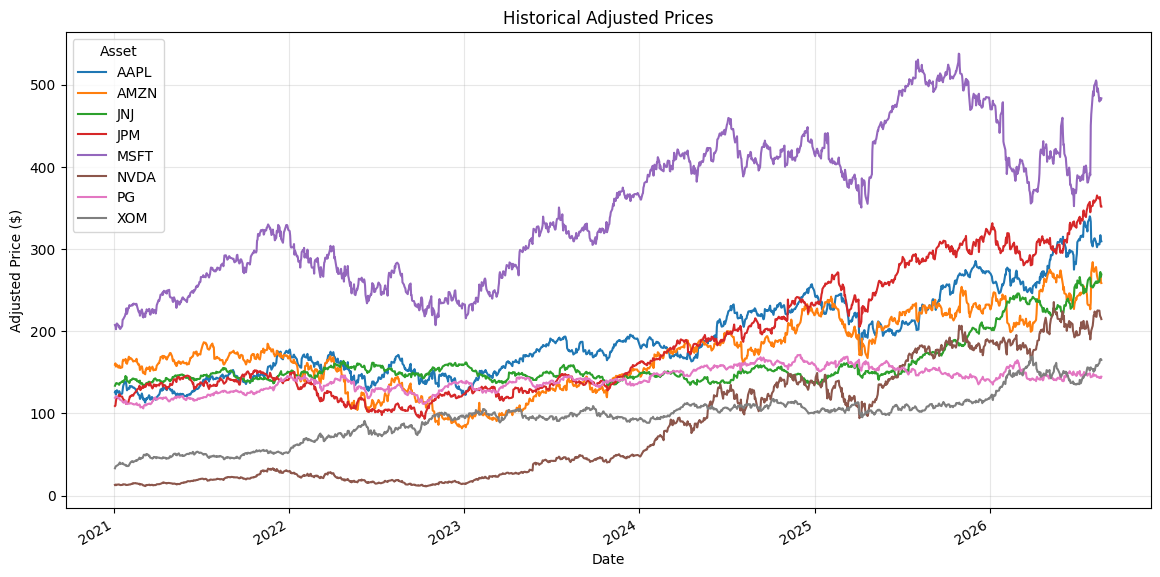

In [740]:
prices.plot(
    figsize=(14, 7),
    title = "Historical Adjusted Prices"
)
plt.ylabel("Adjusted Price ($)")
plt.xlabel("Date")
plt.legend(title="Asset")
plt.grid(alpha=0.3)
plt.show()

### Daily Return Calculation

Before calculating returns for the full dataset, the return formula is verified manually for one AAPL observation.

For two consecutive prices $P_{t-1}$ and $P_t$:

$$
r_t = \frac{P_t}{P_{t-1}} - 1
$$

The same calculation is then vectorized across the full price dataset using `pct_change()`.

In [741]:
aapl_return = (
    prices["AAPL"].iloc[1]
    / prices["AAPL"].iloc[0]
    - 1
)

print(
    f"AAPL first daily return: "
    f"{aapl_return:.4%}"
)

AAPL first daily return: 1.2363%


In [742]:
returns = (prices.pct_change().dropna())
returns.head()

Ticker,AAPL,AMZN,JNJ,JPM,MSFT,NVDA,PG,XOM
Date,,,,,,,,
2021-01-05,0.012363,0.010004,0.011757,0.005441,0.000964,0.022210,0.006385,0.048193
2021-01-06,-0.033661,-0.024897,0.009410,0.046956,-0.025929,-0.058953,0.010527,0.025517
2021-01-07,0.034123,0.007577,0.003379,0.032839,0.028457,0.057830,-0.009347,0.007846
2021-01-08,0.008631,0.006496,-0.002058,0.001104,0.006093,-0.005040,-0.000432,0.011121
2021-01-11,-0.023249,-0.021519,-0.004186,0.014924,-0.009698,0.025966,-0.006773,0.030356


### Annualized Return and Volatility

Daily observations are annualized using approximately 252 trading days per year.

Expected annual return:

$$
E[R_i]_{\text{annual}}
=
252 \times \bar r_i
$$

Annualized volatility:

$$
\sigma_{i,\text{annual}}
=
\sigma_{i,\text{daily}}\sqrt{252}
$$

The square-root-of-time rule is used for volatility because variance accumulates approximately linearly through time under the standard independent-return assumption.

In [743]:
annual_returns = (returns.mean() * 252)

annual_volatility = (returns.std() * np.sqrt(252))

asset_summary = pd.DataFrame({
    "Annual Return": annual_returns,
    "Annual Volatility": annual_volatility
})

(asset_summary * 100).round(2)

,Annual Return,Annual Volatility
Ticker,,
AAPL,19.92,27.81
AMZN,14.82,35.25
JNJ,13.95,17.23
JPM,23.79,24.16
MSFT,18.79,27.39
NVDA,62.71,50.80
PG,5.07,17.78
XOM,32.29,27.23


## 3. Portfolio Mathematics & Diversification

Portfolio risk depends not only on the volatility of individual assets, but also on how those assets move relative to one another.

To analyze these relationships, this section examines covariance and correlation across the asset universe and then applies matrix algebra to calculate portfolio expected return and variance.

For a portfolio with weight vector $w$ and expected-return vector $\mu$, expected portfolio return is:

$$
E[R_p] = w^T \mu
$$

Portfolio variance is:

$$
\sigma_p^2 = w^T \Sigma w
$$

where:

- $w$ = vector of portfolio weights
- $\mu$ = vector of expected asset returns
- $\Sigma$ = covariance matrix
- $w^T$ = transpose of the weight vector

Portfolio volatility is therefore:

$$
\sigma_p = \sqrt{w^T \Sigma w}
$$

The covariance terms allow diversification to reduce portfolio risk when assets do not move perfectly together.

In [744]:
#  Covariance Matrix (Σ)
cov_matrix_daily = returns.cov()
cov_matrix_daily.round(5)

Ticker,AAPL,AMZN,JNJ,JPM,MSFT,NVDA,PG,XOM
Ticker,,,,,,,,
AAPL,0.00031,0.00019,0.00003,0.00009,0.00016,0.00027,0.00005,0.00005
AMZN,0.00019,0.00049,-0.00000,0.00011,0.00023,0.00038,0.00002,0.00003
JNJ,0.00003,-0.00000,0.00012,0.00003,0.00000,-0.00004,0.00005,0.00002
JPM,0.00009,0.00011,0.00003,0.00023,0.00007,0.00015,0.00003,0.00008
MSFT,0.00016,0.00023,0.00000,0.00007,0.00030,0.00031,0.00003,0.00001
NVDA,0.00027,0.00038,-0.00004,0.00015,0.00031,0.00102,-0.00000,0.00003
PG,0.00005,0.00002,0.00005,0.00003,0.00003,-0.00000,0.00013,0.00001
XOM,0.00005,0.00003,0.00002,0.00008,0.00001,0.00003,0.00001,0.00029


### Covariance Matrix

Covariance measures how the returns of two assets move together.

- Positive covariance indicates that two assets tend to move in the same direction.
- Negative covariance indicates that they tend to move in opposite directions.
- Covariance near zero indicates a weak linear relationship.

The daily covariance matrix is annualized by multiplying by 252 trading days.

In [745]:
# Annualizing the covariance matrix
cov_matrix = cov_matrix_daily * 252
cov_matrix

Ticker,AAPL,AMZN,JNJ,JPM,MSFT,NVDA,PG,XOM
Ticker,,,,,,,,
AAPL,0.077360,0.049008,0.006769,0.021955,0.041466,0.068195,0.011815,0.011377
AMZN,0.049008,0.124287,-0.000364,0.027306,0.058852,0.094587,0.005663,0.006822
JNJ,0.006769,-0.000364,0.029696,0.007318,0.000498,-0.009383,0.013700,0.006103
JPM,0.021955,0.027306,0.007318,0.058382,0.017847,0.037173,0.007279,0.020209
MSFT,0.041466,0.058852,0.000498,0.017847,0.075041,0.078966,0.006911,0.003608
NVDA,0.068195,0.094587,-0.009383,0.037173,0.078966,0.258025,-0.001022,0.007926
PG,0.011815,0.005663,0.013700,0.007279,0.006911,-0.001022,0.031595,0.002446
XOM,0.011377,0.006822,0.006103,0.020209,0.003608,0.007926,0.002446,0.074151


In [746]:
print(np.sqrt(cov_matrix.loc["AAPL","AAPL"]))

0.27813630153358765


In [747]:
# Correlation Matrix
correlation_matrix = returns.corr()
correlation_matrix.round(2)

Ticker,AAPL,AMZN,JNJ,JPM,MSFT,NVDA,PG,XOM
Ticker,,,,,,,,
AAPL,1.00,0.50,0.14,0.33,0.54,0.48,0.24,0.15
AMZN,0.50,1.00,-0.01,0.32,0.61,0.53,0.09,0.07
JNJ,0.14,-0.01,1.00,0.18,0.01,-0.11,0.45,0.13
JPM,0.33,0.32,0.18,1.00,0.27,0.30,0.17,0.31
MSFT,0.54,0.61,0.01,0.27,1.00,0.57,0.14,0.05
NVDA,0.48,0.53,-0.11,0.30,0.57,1.00,-0.01,0.06
PG,0.24,0.09,0.45,0.17,0.14,-0.01,1.00,0.05
XOM,0.15,0.07,0.13,0.31,0.05,0.06,0.05,1.00


### Correlation Matrix

Correlation standardizes covariance to a range between -1 and +1:

$$
\rho_{ij}
=
\frac{\operatorname{Cov}(R_i,R_j)}
{\sigma_i \sigma_j}
$$

A correlation of:

- $+1$ indicates perfect positive movement
- $0$ indicates no linear relationship
- $-1$ indicates perfect negative movement

Lower correlations between portfolio assets create greater potential diversification benefits.

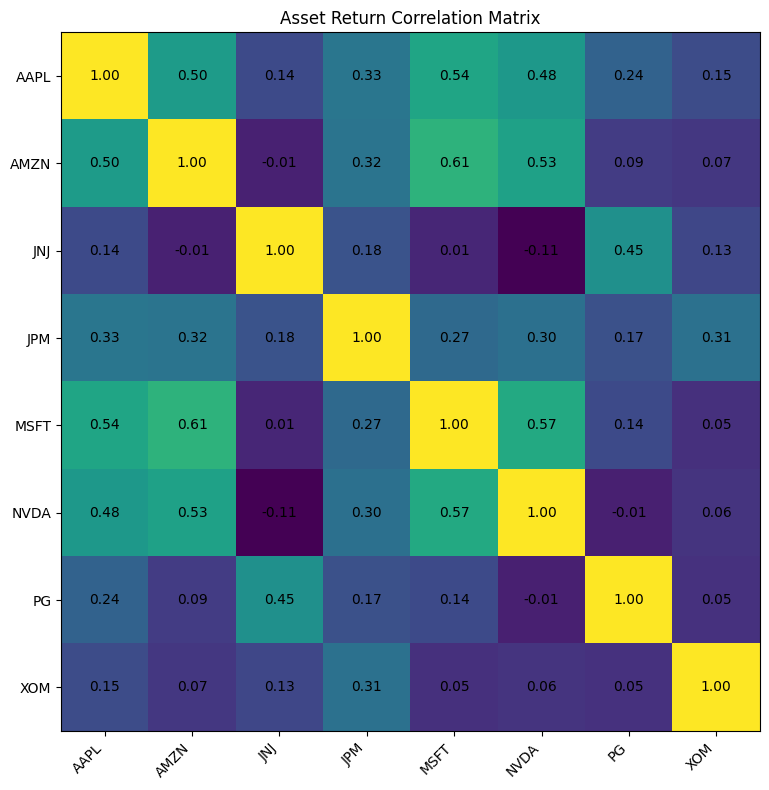

In [748]:
fig, ax = plt.subplots(figsize = (10, 8))

im = ax.imshow(correlation_matrix)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(correlation_matrix.columns)
ax.set_yticklabels(correlation_matrix.index)

plt.setp(
    ax.get_xticklabels(),
    rotation = 45,
    ha = "right"
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Asset Return Correlation Matrix")

plt.tight_layout()
plt.show()

### Equal-Weight Portfolio

Before introducing optimization, an equal-weight portfolio is constructed as a simple benchmark.

With $N$ assets, each asset receives weight:

$$
w_i = \frac{1}{N}
$$

For eight assets, each position therefore receives a weight of 12.5%.

The portfolio weights must satisfy:

$$
\sum_{i=1}^{N} w_i = 1
$$

In [749]:
n_assets = len(tickers)
equal_weights = np.repeat(1/n_assets, n_assets)
equal_weights

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

In [750]:
print(f"Number of assets: {n_assets}")

print(f"Weight per asset: {equal_weights[0]:.2%}")

print(f"Sum of weights: {equal_weights.sum():.2f}")

Number of assets: 8
Weight per asset: 12.50%
Sum of weights: 1.00


In [751]:
annual_returns

Ticker
AAPL    0.199162
AMZN    0.148218
JNJ     0.139488
JPM     0.237933
MSFT    0.187935
NVDA    0.627112
PG      0.050708
XOM     0.322852
dtype: float64

In [752]:
equal_weight_return = equal_weights @ annual_returns   # '@' operator means matrix / vector multiplication or dot product
print(f"Equal-Weight Expected Return: "
      f"{equal_weight_return:.2%}")



Equal-Weight Expected Return: 23.92%


In [753]:
# portfolio variance and volatility
equal_weight_variance = (equal_weights @ cov_matrix @ equal_weights)

equal_weight_volatility = ( np.sqrt(equal_weight_variance))

print(f"Equal-Weight Portfolio Variance: "
    f"{equal_weight_variance:.4f}"
)

print(f"Equal-Weight Portfolio Volatility: "
    f"{equal_weight_volatility:.2%}"
)

Equal-Weight Portfolio Variance: 0.0302
Equal-Weight Portfolio Volatility: 17.39%


### Diversification Benefit

Portfolio volatility is not simply the weighted average of the individual asset volatilities.

If all assets moved perfectly together, diversification would provide little or no risk reduction. However, because correlations across assets are generally less than +1, some asset movements partially offset others.

To illustrate this effect, the weighted-average individual volatility is compared with the actual portfolio volatility.

The diversification benefit is defined here as:

$$
\text{Diversification Benefit}
=
\sum_{i=1}^{N} w_i \sigma_i
-
\sigma_p
$$

A positive value indicates that combining the assets reduces portfolio volatility relative to simply averaging their individual risks.

In [754]:
weighted_average_volatility = (equal_weights @ annual_volatility
)

diversification_benefit = (
    weighted_average_volatility
    - equal_weight_volatility
)

print(f"Weighted Average Individual Volatility: "
    f"{weighted_average_volatility:.2%}"
)

print(f"Actual Portfolio Volatility: "
    f"{equal_weight_volatility:.2%}"
)

print(f"Diversification Benefit: "
    f"{diversification_benefit:.2%}"
)

Weighted Average Individual Volatility: 28.46%
Actual Portfolio Volatility: 17.39%
Diversification Benefit: 11.07%


### Interpretation

The equal-weight portfolio has a weighted-average individual volatility of 28.46%, but its actual portfolio volatility is only 17.39%.

This represents a diversification benefit of 11.07 percentage points.

The reduction occurs because the assets are not perfectly positively correlated. Their returns do not move together one-for-one, so some fluctuations offset each other within the portfolio.

This illustrates the importance of the covariance matrix in portfolio construction: portfolio risk depends not only on each asset's standalone volatility, but also on how the assets move relative to one another.

## 4. Monte Carlo Portfolio Simulation

The equal-weight portfolio represents only one possible allocation across the eight assets.

To explore a much larger set of possible portfolios, Monte Carlo simulation is used to generate 50,000 random portfolio weight combinations.

For each simulated portfolio:

1. Random weights are generated.
2. The weights are normalized so that they sum to 1.
3. Expected portfolio return is calculated as:

$$
E[R_p] = w^T \mu
$$

4. Portfolio volatility is calculated as:

$$
\sigma_p = \sqrt{w^T \Sigma w}
$$

5. The Sharpe ratio is calculated as:

$$
\text{Sharpe Ratio}
=
\frac{E[R_p]}{\sigma_p}
$$

A risk-free rate of 0% is assumed for simplicity.

The simulation allows us to visualize the risk-return opportunity set and identify portfolios with attractive combinations of expected return and volatility.

In [755]:
#Generating Random Portfolio 
random_weights = np.random.random(n_assets)
random_weights

array([0.9391995 , 0.80512158, 0.13099955, 0.83487945, 0.79591536,
       0.02536118, 0.74081262, 0.60596135])

In [756]:
random_weights = (random_weights / random_weights.sum())

print(f"Sum of weights: {random_weights.sum():.2f}")

random_weights

Sum of weights: 1.00


array([0.19252793, 0.1650431 , 0.0268538 , 0.17114321, 0.1631559 ,
       0.00519883, 0.15186031, 0.12421694])

In [757]:
np.random.random(n_assets)

array([0.107435  , 0.15980929, 0.3929867 , 0.43557377, 0.01291395,
       0.63122167, 0.32883765, 0.18844095])

In [758]:
random_weights.sum()

np.float64(1.0)

### Random Portfolio Generation

Random numbers are first generated for each asset and then normalized so that the portfolio weights sum to 1.

If the initial random values are represented by $x_i$, the normalized portfolio weight is:

$$
w_i =
\frac{x_i}
{\sum_{j=1}^{N} x_j}
$$

This produces a long-only portfolio in which all weights are non-negative and the total allocation equals 100%.

In [759]:
random_portfolio = pd.Series(
    random_weights,
    index = annual_returns.index,
    name="Weight"
)
(random_portfolio * 100).round(2)

Ticker
AAPL    19.25
AMZN    16.50
JNJ      2.69
JPM     17.11
MSFT    16.32
NVDA     0.52
PG      15.19
XOM     12.42
Name: Weight, dtype: float64

In [760]:
# Calculating random portfolio returns

random_portfolio_return = (random_weights @ annual_returns
)

random_portfolio_variance = (
    random_weights
    @ cov_matrix
    @ random_weights
)

random_portfolio_volatility = (np.sqrt(random_portfolio_variance)
)

random_portfolio_sharpe = (
    random_portfolio_return
    / random_portfolio_volatility
)

print(
    f"Expected Return: "
    f"{random_portfolio_return:.2%}"
)

print(
    f"Volatility: "
    f"{random_portfolio_volatility:.2%}"
)

print(
    f"Sharpe Ratio: "
    f"{random_portfolio_sharpe:.3f}"
)

Expected Return: 18.90%
Volatility: 17.07%
Sharpe Ratio: 1.107


In [761]:
# Generating randomly 50000 portfolio
num_portfolios = 50000

portfolio_returns = np.zeros(num_portfolios)
portfolio_volatilities = np.zeros(num_portfolios)
portfolio_sharpe = np.zeros(num_portfolios)

all_weights = np.zeros(
    (num_portfolios, n_assets))


In [762]:
portfolio_returns

array([0., 0., 0., ..., 0., 0., 0.], shape=(50000,))

In [763]:
all_weights.shape

(50000, 8)

In [764]:
for i in range(num_portfolios):

    # Generate random portfolio weights
    weights_i = np.random.random(n_assets)

    # Make weights sum to 1
    weights_i = weights_i / weights_i.sum()

    # Store weights
    all_weights[i, :] = weights_i

    # Expected portfolio return
    portfolio_returns[i] = (
        weights_i @ annual_returns
    )

    # portfolio variance
    portfolio_variance_i = (
        weights_i.T @ cov_matrix @ weights_i
    )

    # Portfolio volatility
    portfolio_volatilities[i] = np.sqrt(portfolio_variance_i)

    # Sharpe ratio
    portfolio_sharpe[i] = (
        portfolio_returns[i] / portfolio_volatilities[i]
    )


In [765]:
portfolio_returns[:5]

array([0.21734974, 0.27556045, 0.23889002, 0.25680312, 0.25224967])

In [766]:
portfolio_volatilities[:5]

array([0.17512367, 0.1975881 , 0.17682647, 0.17117533, 0.16320915])

In [767]:
portfolio_sharpe[:5]

array([1.24112144, 1.39462068, 1.35098564, 1.50023438, 1.54556082])

In [768]:
all_weights[:3]

array([[0.21001876, 0.1409023 , 0.07577829, 0.30110582, 0.09878174,
        0.00414896, 0.01245388, 0.15681025],
       [0.1536968 , 0.04083047, 0.00978603, 0.16313173, 0.05788462,
        0.23512994, 0.25440307, 0.08513733],
       [0.09574577, 0.13333065, 0.12864834, 0.13508088, 0.09668205,
        0.15482023, 0.17577641, 0.07991568]])

In [769]:
all_weights[:3].sum(axis=1)

array([1., 1., 1.])

### Monte Carlo Risk-Return Opportunity Set

Each point in the following chart represents one randomly generated portfolio.

The horizontal axis shows annualized portfolio volatility, while the vertical axis shows expected annual return.

Portfolios are colored according to their Sharpe ratio. A higher Sharpe ratio indicates more expected return per unit of risk.

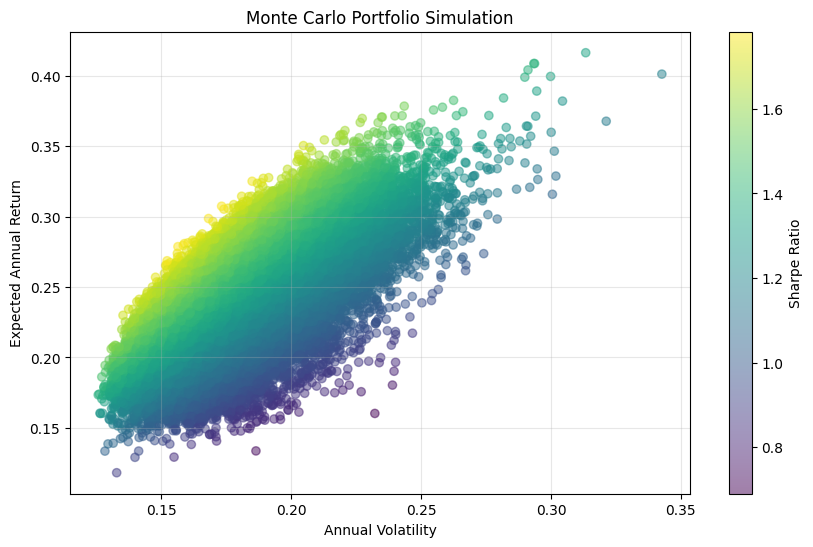

In [770]:
plt.figure(figsize=(10, 6))

plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    c = portfolio_sharpe,
    alpha=0.5
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Monte Carlo Portfolio Simulation")

plt.colorbar(label= "Sharpe Ratio")
plt.grid(alpha=0.3)
plt.show()

In [771]:
# for the approximate minimum-volatility portfolio

min_vol_index = np.argmin(portfolio_volatilities)

min_vol_return = portfolio_returns[min_vol_index]

min_vol_volatility = portfolio_volatilities[min_vol_index]

min_vol_sharpe = portfolio_sharpe[min_vol_index]

min_vol_weights = all_weights[min_vol_index]

In [772]:
# For the approximate-Sharpe portfolio

max_sharpe_index = np.argmax(portfolio_sharpe)

max_sharpe_return = portfolio_returns[max_sharpe_index]

max_sharpe_volatility = portfolio_volatilities[max_sharpe_index]

max_sharpe_ratio = portfolio_sharpe[max_sharpe_index]

max_sharpe_weights = all_weights[max_sharpe_index]

In [773]:
print("Minimum-Volatility Portfolio")

print(f"Return: {min_vol_return:.2%}")
print(f"Volatility: {min_vol_volatility:.2%}")

print()

print("Maximum-Sharpe Portfolio")

print(f"Return: {max_sharpe_return:.2%}")
print(f"Volatility: {max_sharpe_volatility:.2%}")
print(f"Sharpe Ratio: "
    f"{portfolio_sharpe[max_sharpe_index]:.3f}")

Minimum-Volatility Portfolio
Return: 17.35%
Volatility: 12.56%

Maximum-Sharpe Portfolio
Return: 27.86%
Volatility: 15.63%
Sharpe Ratio: 1.782


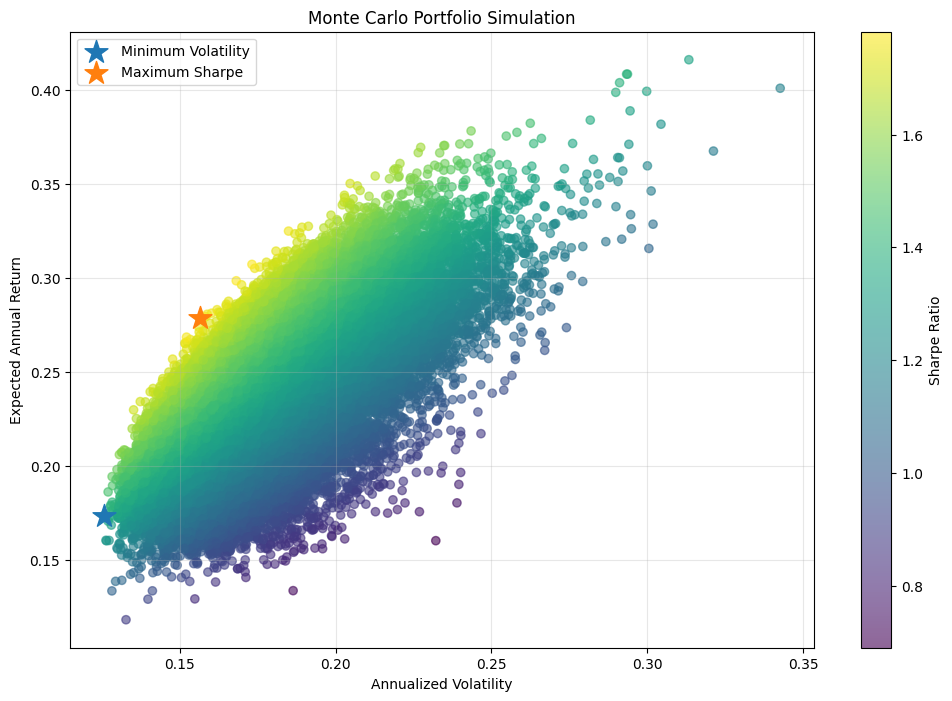

In [774]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    c=portfolio_sharpe,
    alpha=0.6
)

plt.scatter(
    min_vol_volatility,
    min_vol_return,
    marker="*",
    s=300,
    label="Minimum Volatility"
)

plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=300,
    label="Maximum Sharpe"
)

plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Monte Carlo Portfolio Simulation")

plt.colorbar(
    scatter,
    label="Sharpe Ratio"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [775]:
min_vol_weights_series = pd.Series(
    min_vol_weights,
    index=annual_returns.index,
    name="Minimum Volatility"
)

max_sharpe_weights_series = pd.Series(
    max_sharpe_weights,
    index=annual_returns.index,
    name="Maximum Sharpe"
)

portfolio_weight_comparison = pd.concat(
    [
        min_vol_weights_series,
        max_sharpe_weights_series
    ],
    axis=1
)

(portfolio_weight_comparison * 100).round(2)

,Minimum Volatility,Maximum Sharpe
Ticker,,
AAPL,1.42,3.36
AMZN,3.78,1.57
JNJ,30.79,34.79
JPM,12.93,3.52
MSFT,8.36,9.41
NVDA,2.77,15.49
PG,25.97,1.83
XOM,13.97,30.03


### Interpretation

The Monte Carlo simulation demonstrates that different combinations of the same assets can produce substantially different risk-return profiles.

The minimum-volatility portfolio lies near the left edge of the opportunity set, representing one of the lowest-risk allocations found by the simulation.

The maximum-Sharpe portfolio provides the highest estimated return per unit of volatility among the 50,000 randomly generated portfolios.

Because Monte Carlo simulation relies on randomly generated weights, these portfolios are approximate solutions rather than exact mathematical optima.

## 5. Mean-Variance Optimization & Efficient Frontier

Monte Carlo simulation approximates attractive portfolios by randomly sampling many possible weight combinations.

However, random simulation does not guarantee that the true minimum-variance or maximum-Sharpe portfolio will be sampled.

Numerical optimization can solve directly for portfolio weights that satisfy a specific objective.

Two optimization problems are considered:

### Minimum-Variance Portfolio

The objective is to minimize portfolio variance:

$$
\min_w \quad w^T \Sigma w
$$

subject to:

$$
\sum_{i=1}^{N} w_i = 1
$$

and:

$$
0 \leq w_i \leq 1
$$

### Maximum-Sharpe Portfolio

The objective is to maximize:

$$
\text{Sharpe Ratio}
=
\frac{w^T \mu}
{\sqrt{w^T \Sigma w}}
$$

Because numerical optimization routines are generally designed for minimization, the negative Sharpe ratio is minimized instead.

The optimization uses Sequential Least Squares Programming (SLSQP), which allows both equality constraints and bounds on portfolio weights.

In [776]:
# Working on Actual Optimizaton
from scipy.optimize import minimize

In [777]:

def portfolio_return(weights, annual_returns):
    return weights @ annual_returns


def portfolio_volatility(weights, cov_matrix):
    portfolio_variance = (
        weights
        @ cov_matrix
        @ weights
    )

    return np.sqrt(
        portfolio_variance
    )

In [778]:
portfolio_return(weights, annual_returns)

np.float64(0.2795312478732545)

In [779]:
portfolio_volatility(weights, cov_matrix)

np.float64(0.1641865989174682)

In [780]:
def portfolio_sharpe(weights, annual_returns, cov_matrix):

    expected_return = portfolio_return(weights, annual_returns)

    volatility = portfolio_volatility(weights, cov_matrix)

    return (expected_return / volatility)

In [781]:
def negative_sharpe (weights, annual_returns, cov_matrix):
    return -portfolio_sharpe(weights, annual_returns, cov_matrix)


In [782]:
# Setting the starting guess, constraints, and bounds
initial_weights = np.repeat(1 / n_assets, n_assets)

constraints = {
    "type": "eq",
    "fun": lambda weights: (
        np.sum(weights) - 1
    )
}

bounds = tuple(
    (0, 1)
    for _ in range(n_assets)
)

In [783]:
np.sum(weights) - 1


np.float64(0.0)

In [784]:
min_variance_result = minimize(
    fun=portfolio_volatility,
    x0=initial_weights,
    args=(cov_matrix, ),
    method = "SLSQP",
    bounds = bounds,
    constraints = constraints
)


In [785]:
min_variance_weights = min_variance_result.x

In [786]:
# Calculating the portfolio metrics
min_variance_return = portfolio_return(min_variance_weights, annual_returns)

min_variance_volatility = portfolio_volatility(min_variance_weights, cov_matrix)


In [787]:
print(
    f"Optimized Minimum-Variance Return: "
    f"{min_variance_return:.2%}"
)

print(
    f"Optimized Minimum-Variance Volatility: "
    f"{min_variance_volatility:.2%}"
)

print(
    f"Optimization Successful: "
    f"{min_variance_result.success}"
)

Optimized Minimum-Variance Return: 16.06%
Optimized Minimum-Variance Volatility: 12.42%
Optimization Successful: True


In [788]:
min_variance_weights_series = pd.Series(
    min_variance_weights,
    index=annual_returns.index,
    name="Optimized Minimum Variance"
)

(min_variance_weights_series * 100).round(2)

Ticker
AAPL     0.00
AMZN     1.80
JNJ     34.32
JPM      8.30
MSFT    12.37
NVDA     1.27
PG      28.02
XOM     13.91
Name: Optimized Minimum Variance, dtype: float64

### Exact Minimum-Variance Portfolio

The Monte Carlo simulation identifies an approximate minimum-volatility portfolio from a finite set of randomly generated allocations.

Numerical optimization instead searches directly for the portfolio weights that minimize volatility subject to the portfolio constraints.

Therefore, the optimized minimum-variance portfolio should achieve volatility that is equal to or lower than the best randomly generated Monte Carlo portfolio.

In [789]:
max_sharpe_result = minimize(
    fun=negative_sharpe,
    x0=initial_weights,
    args=(annual_returns, cov_matrix),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [790]:
max_sharpe_opt_weights = (max_sharpe_result.x)

In [791]:
# Calculating the metrics
max_sharpe_return = portfolio_return(max_sharpe_opt_weights, annual_returns)

max_sharpe_volatility = portfolio_volatility(max_sharpe_opt_weights, cov_matrix)

max_sharpe_ratio = portfolio_sharpe( max_sharpe_opt_weights, annual_returns, cov_matrix)

In [792]:
print(
    f"Optimized Maximum-Sharpe Return: "
    f"{max_sharpe_return:.2%}"
)

print(
    f"Optimized Maximum-Sharpe Volatility: "
    f"{max_sharpe_volatility:.2%}"
)

print(
    f"Optimized Sharpe Ratio: "
    f"{max_sharpe_ratio:.3f}"
)

print(
    f"Optimization Successful: "
    f"{max_sharpe_result.success}"
)

Optimized Maximum-Sharpe Return: 30.72%
Optimized Maximum-Sharpe Volatility: 16.56%
Optimized Sharpe Ratio: 1.855
Optimization Successful: True


In [793]:
max_sharpe_weights_series = pd.Series(
    max_sharpe_opt_weights,
    index=annual_returns.index,
    name="Optimized Maximum Sharpe"
)

(max_sharpe_weights_series * 100).round(2)

Ticker
AAPL     0.00
AMZN     0.00
JNJ     40.48
JPM      6.97
MSFT     0.00
NVDA    21.20
PG       0.00
XOM     31.35
Name: Optimized Maximum Sharpe, dtype: float64

### Exact Maximum-Sharpe Portfolio

The maximum-Sharpe portfolio is obtained by directly optimizing the portfolio weights rather than relying on random sampling.

Because the numerical optimizer searches systematically within the feasible weight space, the optimized Sharpe ratio should be equal to or higher than the best Sharpe ratio found through Monte Carlo simulation.

### Efficient Frontier

The efficient frontier represents the set of portfolios that provide the highest expected return for a given level of risk.

Portfolios below the frontier are inefficient because another portfolio exists with either:

- higher expected return for the same level of volatility, or
- lower volatility for the same expected return.

To construct the efficient frontier, a sequence of target returns is selected. For each target return, portfolio volatility is minimized subject to:

$$
\sum_{i=1}^{N} w_i = 1
$$

and:

$$
w^T\mu = R_{\text{target}}
$$

The resulting minimum-volatility portfolios trace the efficient frontier.

In [794]:
target_returns = np.linspace(
    min_variance_return,
    annual_returns.max(),
    50
)

In [795]:
frontier_volatilities = []

In [796]:
for target_return in target_returns:

    target_constraints = (
        {
            "type": "eq",
            "fun": lambda weights: (
                np.sum(weights) - 1
            )
        },
        {
            "type": "eq",
            "fun": lambda weights,
            target=target_return: (
                portfolio_return(
                    weights,
                    annual_returns
                )
                - target
            )
        }
    )

    result = minimize(
        fun=portfolio_volatility,
        x0=initial_weights,
        args=(cov_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=target_constraints
    )

    if result.success:
        frontier_volatilities.append(
            result.fun
        )
    else:
        frontier_volatilities.append(
            np.nan
        )

In [797]:
portfolio_return(weights, annual_returns) -1 

np.float64(-0.7204687521267454)

In [798]:
monte_carlo_sharpe = (portfolio_returns / portfolio_volatilities)

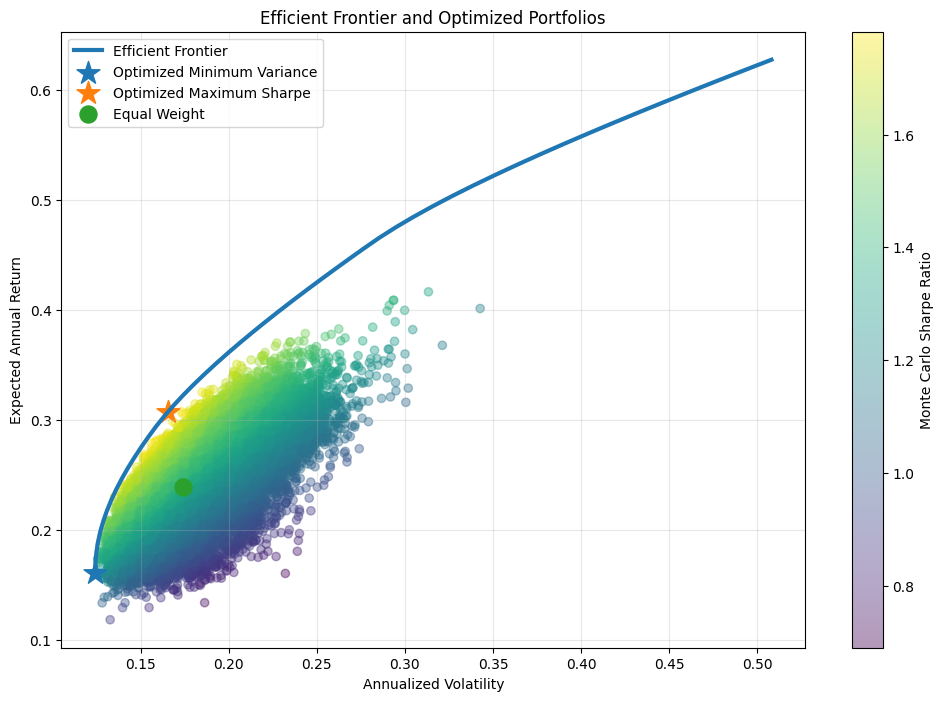

In [799]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    c=monte_carlo_sharpe,
    alpha=0.4
)

plt.plot(
    frontier_volatilities,
    target_returns,
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    min_variance_volatility,
    min_variance_return,
    marker="*",
    s=300,
    label="Optimized Minimum Variance"
)

plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=300,
    label="Optimized Maximum Sharpe"
)

plt.scatter(
    equal_weight_volatility,
    equal_weight_return,
    marker="o",
    s=150,
    label="Equal Weight"
)

plt.xlabel(
    "Annualized Volatility"
)

plt.ylabel(
    "Expected Annual Return"
)

plt.title(
    "Efficient Frontier and Optimized Portfolios"
)

plt.colorbar(
    scatter,
    label="Monte Carlo Sharpe Ratio"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation of the Efficient Frontier

The efficient frontier represents the best achievable expected return for different levels of portfolio risk under the long-only investment constraints.

The optimized minimum-variance portfolio lies at the left-most point of the frontier, with an expected annual return of approximately 16.06% and annualized volatility of 12.42%.

The optimized maximum-Sharpe portfolio produces an expected annual return of approximately 30.72% with 16.56% volatility, resulting in a Sharpe ratio of 1.855. This exceeds the best Sharpe ratio identified through the 50,000-portfolio Monte Carlo simulation, demonstrating the advantage of direct numerical optimization over random portfolio sampling.

The equal-weight portfolio lies below the efficient frontier. Based on the historical estimates used in the model, it is therefore not mean-variance efficient.

However, these results are based on historical estimates of expected returns and covariance. A portfolio that appears optimal in-sample may not remain optimal when market conditions change. This motivates the out-of-sample and walk-forward analysis performed later in the project.

# RISK MANAGEMENT MODULE

## 6. Portfolio Risk Analytics

Portfolio optimization describes the expected relationship between return and volatility, but volatility alone does not fully describe investment risk.

This section evaluates the optimized maximum-Sharpe portfolio using several additional risk measures:

- Value at Risk (VaR)
- Expected Shortfall (ES)
- Maximum Drawdown
- Sortino Ratio
- Calmar Ratio

The analysis begins by constructing the historical daily return series of the optimized maximum-Sharpe portfolio.

For portfolio weights $w$ and the vector of asset returns on day $t$, $r_t$, the portfolio return is:

$$
R_{p,t} = w^T r_t
$$

This daily return series forms the basis for the subsequent risk analysis.

In [800]:
# Create daily portfolio returns
optimized_portfolio_daily_returns= ( returns @ max_sharpe_opt_weights)

optimized_portfolio_daily_returns.name=("Optimized Portfolio")

optimized_portfolio_daily_returns.head()

Date
2021-01-05    0.024955
2021-01-06    0.002584
2021-01-07    0.018375
2021-01-08    0.001662
2021-01-11    0.014366
Name: Optimized Portfolio, dtype: float64

In [801]:
optimized_portfolio_daily_returns.shape

(1414,)

In [802]:
print(
    f"Observations: "
    f"{len(optimized_portfolio_daily_returns):,}"
)

print(
    f"Average Daily Return: "
    f"{optimized_portfolio_daily_returns.mean():.4%}"
)

print(
    f"Daily Volatility: "
    f"{optimized_portfolio_daily_returns.std():.4%}"
)

Observations: 1,414
Average Daily Return: 0.1219%
Daily Volatility: 1.0431%


In [803]:
annualized_portfolio_volatility = (
    optimized_portfolio_daily_returns.std()
    * np.sqrt(252)
)

print(
    f"Annualized Volatility: "
    f"{annualized_portfolio_volatility:.2%}"
)

print(
    f"Optimization Volatility: "
    f"{max_sharpe_volatility:.2%}"
)

Annualized Volatility: 16.56%
Optimization Volatility: 16.56%


### Historical Value at Risk (VaR)

Value at Risk (VaR) estimates the loss threshold that is expected to be exceeded only with a specified probability over a given time horizon.

For example, a one-day 95% VaR of 1.5% means that approximately 95% of historical daily outcomes were better than a 1.5% loss, while approximately 5% were worse.

Historical VaR makes no assumption about the shape of the return distribution. Instead, it uses the actual historical portfolio return observations.

For a confidence level $c$, historical VaR is calculated from the lower tail of the return distribution:

$$
\text{VaR}_{c} = -Q_{1-c}(R_p)
$$

where $Q_{1-c}(R_p)$ is the corresponding lower-tail percentile of historical portfolio returns.

In [804]:
var_95_return = np.percentile(optimized_portfolio_daily_returns, 5)

var_99_return = np.percentile(optimized_portfolio_daily_returns, 1)

print(
    f"5th Percentile Return: "
    f"{var_95_return:.4%}"
)

print(
    f"1st Percentile Return: "
    f"{var_99_return:.4%}"
)

5th Percentile Return: -1.5646%
1st Percentile Return: -2.6214%


In [805]:
historical_var_95 = -var_95_return
historical_var_99 = -var_99_return

print(
    f"Historical VaR 95%: "
    f"{historical_var_95:.4%}"
)

print(
    f"Historical VaR 99%: "
    f"{historical_var_99:.4%}"
)

Historical VaR 95%: 1.5646%
Historical VaR 99%: 2.6214%


In [806]:
portfolio_value = 1000000

In [807]:
historical_var_95_dollars = (
    historical_var_95
    * portfolio_value
)

historical_var_99_dollars = (
    historical_var_99
    * portfolio_value
)

print(
    f"95% One-Day VaR: "
    f"${historical_var_95_dollars:,.2f}"
)

print(
    f"99% One-Day VaR: "
    f"${historical_var_99_dollars:,.2f}"
)

95% One-Day VaR: $15,645.66
99% One-Day VaR: $26,213.59


### Expected Shortfall (ES)

Expected Shortfall measures the average loss that occurs when portfolio losses exceed the Value at Risk threshold.

While VaR identifies the cutoff for extreme losses, Expected Shortfall estimates the average severity of losses beyond that cutoff.

For confidence level $c$:

$$
ES_c =
-E[R_p \mid R_p \leq Q_{1-c}(R_p)]
$$

Therefore, Expected Shortfall provides more information about tail risk than VaR.

In [808]:
historical_es_95 = -optimized_portfolio_daily_returns[optimized_portfolio_daily_returns <= var_95_return].mean()

historical_es_95

np.float64(0.022460197721785962)

In [809]:
historical_es_99 = -optimized_portfolio_daily_returns[
    optimized_portfolio_daily_returns <= var_99_return
].mean()

historical_es_99


np.float64(0.03406020507490916)

In [810]:
historical_es_95_dollars = (
    historical_es_95
    * portfolio_value
)

historical_es_99_dollars = (
    historical_es_99
    * portfolio_value
)

print(
    f"Historical ES 95%: "
    f"{historical_es_95:.4%} "
    f"(${historical_es_95_dollars:,.2f})"
)

print(
    f"Historical ES 99%: "
    f"{historical_es_99:.4%} "
    f"(${historical_es_99_dollars:,.2f})"
)

Historical ES 95%: 2.2460% ($22,460.20)
Historical ES 99%: 3.4060% ($34,060.21)


In [811]:
risk_comparison = pd.DataFrame({
    "95%": [
        historical_var_95,
        historical_es_95
    ],
    "99%": [
        historical_var_99,
        historical_es_99
    ]
}, index=[
    "Historical VaR",
    "Historical ES"
])

(risk_comparison * 100).round(2)

,95%,99%
Historical VaR,1.56,2.62
Historical ES,2.25,3.41


### Historical Tail-Risk Interpretation

Historical VaR identifies the threshold at which extreme portfolio losses begin, while Expected Shortfall measures the average severity of losses beyond that threshold.

For the $1 million portfolio, the 95% VaR is approximately $15,646, while the corresponding Expected Shortfall is approximately $22,460. At the 99% confidence level, VaR increases to approximately $26,214 and Expected Shortfall increases to approximately $34,060.

The higher Expected Shortfall values demonstrate that losses can become substantially larger after the VaR threshold has been breached.

### Parametric VaR

Parametric VaR estimates portfolio tail risk by assuming that returns follow a specified probability distribution.

Under the normal-distribution assumption, VaR can be estimated using the portfolio's historical mean return, volatility, and the standard normal critical value.

For a lower-tail probability $\alpha$:

$$
Q_{\alpha}
=
\mu + z_{\alpha}\sigma
$$

where:

- $\mu$ is the mean daily portfolio return,
- $\sigma$ is the daily portfolio volatility,
- $z_{\alpha}$ is the standard normal critical value.

The VaR is then reported as the positive magnitude of this lower-tail return.

In [812]:
daily_mean = (optimized_portfolio_daily_returns.mean())

daily_volatility = (optimized_portfolio_daily_returns.std())

print(f"Daily Mean Return: {daily_mean:.4%}")

print(f"Daily Volatility: {daily_volatility:.4%}")

Daily Mean Return: 0.1219%
Daily Volatility: 1.0431%


In [813]:
from scipy.stats import norm

In [814]:
z_95 = norm.ppf(0.05)
z_99 = norm.ppf(0.01)

print(f"95% Lower-Tail Z-Score: {z_95:.4f}")
print(f"99% Lower-Tail Z-Score: {z_99:.4f}")

95% Lower-Tail Z-Score: -1.6449
99% Lower-Tail Z-Score: -2.3263


In [815]:
parametric_cutoff_95 = (
    daily_mean
    + z_95 * daily_volatility
)

parametric_cutoff_99 = (
    daily_mean
    + z_99 * daily_volatility
)

print(
    f"95% Lower-Tail Return: "
    f"{parametric_cutoff_95:.4%}"
)

print(
    f"99% Lower-Tail Return: "
    f"{parametric_cutoff_99:.4%}"
)

95% Lower-Tail Return: -1.5938%
99% Lower-Tail Return: -2.3047%


In [816]:
parametric_var_95 = -parametric_cutoff_95
parametric_var_99 = -parametric_cutoff_99

print(
    f"Parametric VaR 95%: "
    f"{parametric_var_95:.4%}"
)

print(
    f"Parametric VaR 99%: "
    f"{parametric_var_99:.4%}"
)

Parametric VaR 95%: 1.5938%
Parametric VaR 99%: 2.3047%


In [817]:
parametric_var_95_dollars = (
    parametric_var_95
    * portfolio_value
)

parametric_var_99_dollars = (
    parametric_var_99
    * portfolio_value
)

print(
    f"95% Parametric One-Day VaR: "
    f"${parametric_var_95_dollars:,.2f}"
)

print(
    f"99% Parametric One-Day VaR: "
    f"${parametric_var_99_dollars:,.2f}"
)

95% Parametric One-Day VaR: $15,938.42
99% Parametric One-Day VaR: $23,047.08


In [818]:
var_comparison = pd.DataFrame({
    "Historical VaR": [
        historical_var_95,
        historical_var_99
    ],
    "Parametric VaR": [
        parametric_var_95,
        parametric_var_99
    ]
}, index=[
    "95%",
    "99%"
])

(var_comparison * 100).round(2)

,Historical VaR,Parametric VaR
95%,1.56,1.59
99%,2.62,2.30


### Historical vs. Parametric VaR

Historical VaR uses the actual empirical distribution of portfolio returns, while parametric VaR assumes that returns follow a normal distribution.

At the 95% confidence level, both methods produce relatively similar estimates.

At the 99% confidence level, however, parametric VaR produces a smaller loss estimate than historical VaR.

This suggests that the normal-distribution assumption may underestimate extreme downside risk when the historical return distribution contains heavier tails than the normal distribution.

In [819]:
alpha_95 = 0.05
alpha_99 = 0.01

In [820]:
parametric_es_95 = (
    -daily_mean
    + daily_volatility
    * norm.pdf(z_95)
    / alpha_95
)

parametric_es_99 = (
    -daily_mean
    + daily_volatility
    * norm.pdf(z_99)
    / alpha_99
)

In [821]:
parametric_es_95_dollars = (
    parametric_es_95
    * portfolio_value
)

parametric_es_99_dollars = (
    parametric_es_99
    * portfolio_value
)

print(
    f"95% Parametric ES: "
    f"{parametric_es_95:.4%} "
    f"(${parametric_es_95_dollars:,.2f})"
)

print(
    f"99% Parametric ES: "
    f"{parametric_es_99:.4%} "
    f"(${parametric_es_99_dollars:,.2f})"
)

95% Parametric ES: 2.0297% ($20,297.10)
99% Parametric ES: 2.6582% ($26,581.80)


### Monte Carlo VaR and Expected Shortfall

Monte Carlo simulation estimates portfolio risk by generating a large number of possible future return scenarios.

Rather than directly using historical portfolio returns, the simulation models correlated asset returns using their estimated mean vector and covariance matrix.

To preserve the correlation structure between assets, the covariance matrix is decomposed using Cholesky decomposition:

$$
\Sigma = LL^T
$$

Independent standard-normal random variables are then transformed into correlated return shocks:

$$
r = \mu + Lz
$$

where:

- $\mu$ is the vector of expected daily asset returns,
- $L$ is the Cholesky factor of the covariance matrix,
- $z$ is a vector of independent standard-normal random variables.

The simulated asset returns are then combined using the optimized portfolio weights to generate a distribution of simulated one-day portfolio returns.

In [822]:
daily_asset_mean = returns.mean()

daily_cov_matrix = returns.cov()

In [823]:
cholesky_matrix = np.linalg.cholesky(
    daily_cov_matrix
)

print(cholesky_matrix.shape)

(8, 8)


In [824]:
n_simulations = 100_000

random_shocks = np.random.normal(
    size=(n_simulations, n_assets)
)

In [825]:
random_shocks.shape

(100000, 8)

In [826]:
simulated_asset_returns = (daily_asset_mean.values + random_shocks @ cholesky_matrix.T)

simulated_asset_returns.shape

(100000, 8)

In [827]:
simulated_portfolio_returns = (simulated_asset_returns @ max_sharpe_opt_weights)

simulated_portfolio_returns.shape

(100000,)

In [828]:
mc_var_95_return = np.percentile(
    simulated_portfolio_returns,
    5
)

mc_var_99_return = np.percentile(
    simulated_portfolio_returns,
    1
)

mc_var_95 = -mc_var_95_return
mc_var_99 = -mc_var_99_return

In [829]:
mc_es_95 = -simulated_portfolio_returns[
    simulated_portfolio_returns <= mc_var_95_return
].mean()

mc_es_99 = -simulated_portfolio_returns[
    simulated_portfolio_returns <= mc_var_99_return
].mean()

In [830]:
mc_var_95_dollars = mc_var_95 * portfolio_value
mc_var_99_dollars = mc_var_99 * portfolio_value

mc_es_95_dollars = mc_es_95 * portfolio_value
mc_es_99_dollars = mc_es_99 * portfolio_value

In [831]:
print(
    f"Monte Carlo VaR 95%: "
    f"{mc_var_95:.4%} "
    f"(${mc_var_95_dollars:,.2f})"
)

print(
    f"Monte Carlo VaR 99%: "
    f"{mc_var_99:.4%} "
    f"(${mc_var_99_dollars:,.2f})"
)

print(
    f"Monte Carlo ES 95%: "
    f"{mc_es_95:.4%} "
    f"(${mc_es_95_dollars:,.2f})"
)

print(
    f"Monte Carlo ES 99%: "
    f"{mc_es_99:.4%} "
    f"(${mc_es_99_dollars:,.2f})"
)

Monte Carlo VaR 95%: 1.5953% ($15,953.37)
Monte Carlo VaR 99%: 2.3074% ($23,073.98)
Monte Carlo ES 95%: 2.0300% ($20,299.96)
Monte Carlo ES 99%: 2.6530% ($26,529.89)


In [832]:
tail_risk_comparison = pd.DataFrame({
    "Historical": [
        historical_var_95,
        historical_var_99,
        historical_es_95,
        historical_es_99
    ],
    "Parametric Normal": [
        parametric_var_95,
        parametric_var_99,
        parametric_es_95,
        parametric_es_99
    ],
    "Monte Carlo Normal": [
        mc_var_95,
        mc_var_99,
        mc_es_95,
        mc_es_99
    ]
}, index=[
    "VaR 95%",
    "VaR 99%",
    "ES 95%",
    "ES 99%"
])

(tail_risk_comparison * 100).round(2)

,Historical,Parametric Normal,Monte Carlo Normal
VaR 95%,1.56,1.59,1.60
VaR 99%,2.62,2.30,2.31
ES 95%,2.25,2.03,2.03
ES 99%,3.41,2.66,2.65


### Tail-Risk Comparison

The parametric and Monte Carlo estimates are very similar because both approaches assume normally distributed asset returns based on the estimated mean and covariance structure.

Historical estimates differ more substantially in the extreme tail. In particular, the historical 99% Expected Shortfall is considerably larger than both normal-model estimates.

This suggests that the historical portfolio return distribution contains more severe downside observations than predicted by the normal distribution. The comparison demonstrates why relying on a single risk model can provide an incomplete view of portfolio tail risk.

# Drawdown
- It measures how far our portfolio has fallen from its previous peak

In [833]:
# Building a wealth index
optimized_portfolio_daily_returns

Date
2021-01-05    0.024955
2021-01-06    0.002584
2021-01-07    0.018375
2021-01-08    0.001662
2021-01-11    0.014366
                ...   
2026-08-17    0.007349
2026-08-18    0.016923
2026-08-19   -0.001314
2026-08-20   -0.008123
2026-08-21    0.000307
Name: Optimized Portfolio, Length: 1414, dtype: float64

In [834]:
wealth_index = (
    1  + optimized_portfolio_daily_returns
).cumprod()

wealth_index.head()

Date
2021-01-05    1.024955
2021-01-06    1.027604
2021-01-07    1.046486
2021-01-08    1.048225
2021-01-11    1.063284
Name: Optimized Portfolio, dtype: float64

In [835]:
# calculating the running peak
running_peak = wealth_index.cummax()
running_peak.head()

Date
2021-01-05    1.024955
2021-01-06    1.027604
2021-01-07    1.046486
2021-01-08    1.048225
2021-01-11    1.063284
Name: Optimized Portfolio, dtype: float64

In [836]:
# Calculate the drawdown
drawdown = (wealth_index / running_peak) - 1
drawdown.head()

Date
2021-01-05    0.0
2021-01-06    0.0
2021-01-07    0.0
2021-01-08    0.0
2021-01-11    0.0
Name: Optimized Portfolio, dtype: float64

In [837]:
# maximum drawdown
max_drawdown = drawdown.min()

print(f"Maximum Drawdown: "
      f"{max_drawdown:.2%}")

Maximum Drawdown: -17.25%


### This means, At the worst point in the historical period, the portfolio had fallen 17.25% below its previous peak.


In [838]:
# finding when did the maximum drawdown happen?
max_drawdown_date = drawdown.idxmin()
max_drawdown_date

Timestamp('2022-09-26 00:00:00')

In [839]:
# Finding the peak before that drawdown
peak_date = wealth_index.loc[:max_drawdown_date].idxmax()

print("Peak Date:", peak_date)
print("Max Drawdown Date:", max_drawdown_date)

# value of the portfolio at that peak
peak_value = wealth_index.loc[peak_date]

# date after the trough
after_trough = wealth_index.loc[max_drawdown_date:]

# Dates where the portfolio recovered back to the old peak
recovery_dates = after_trough[after_trough >= peak_value]

Peak Date: 2022-03-30 00:00:00
Max Drawdown Date: 2022-09-26 00:00:00


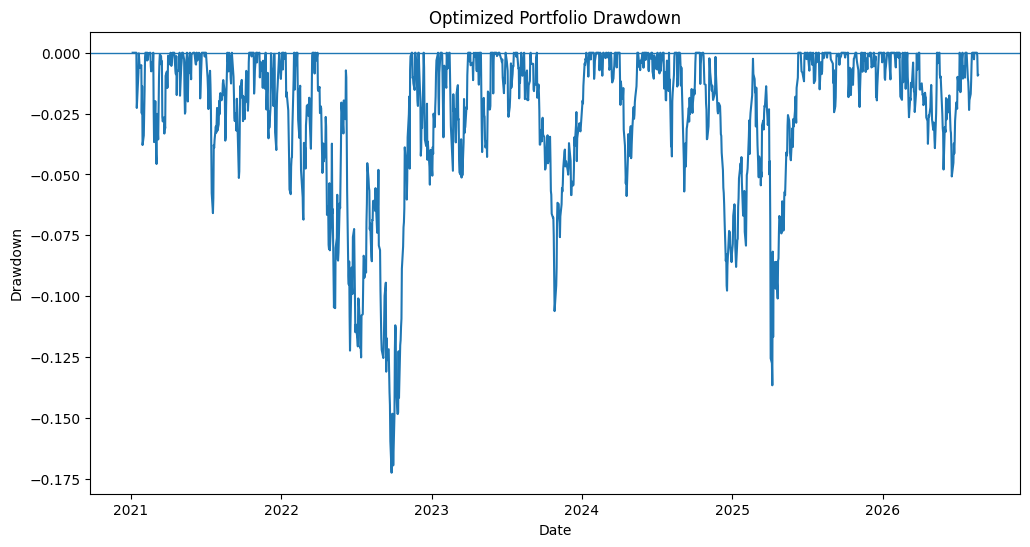

In [840]:
plt.figure(figsize=(12,6))

plt.plot(drawdown.index, drawdown)

plt.axhline(0, linewidth=1)

plt.title("Optimized Portfolio Drawdown")

plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.show()

In [841]:
peak_value = wealth_index.loc[peak_date]

after_trough = wealth_index.loc[max_drawdown_date:]

recovery_date = after_trough[
    after_trough >= peak_value]

if len(recovery_date) > 0:
    recovery_date = recovery_date.index[0]

    print("Peak Date:", peak_date)
    print("Trough Date:", max_drawdown_date)
    print("Recovery Date:", recovery_date)

    print("Peak-to-Trough Days:", (max_drawdown_date - peak_date).days)
    print("Trough-to-Recovery Days:", (recovery_date - max_drawdown_date).days)

    print("Total Drawdown Duration:", (recovery_date - peak_date).days)

else:
    print("Portfolio has not yet recovered.")

Peak Date: 2022-03-30 00:00:00
Trough Date: 2022-09-26 00:00:00
Recovery Date: 2022-11-14 00:00:00
Peak-to-Trough Days: 180
Trough-to-Recovery Days: 49
Total Drawdown Duration: 229


In [842]:
# SORTINO RATIO

target_daily_return=0

downside_returns = (
    optimized_portfolio_daily_returns[optimized_portfolio_daily_returns < target_daily_return]
)

In [843]:
downside_deviation_daily = np.sqrt(np.mean(np.minimum(optimized_portfolio_daily_returns - target_daily_return, 0) **2))

In [844]:
downside_deviation_annual = (
    downside_deviation_daily * np.sqrt(252)
)

In [845]:
annualized_portfolio_return = (optimized_portfolio_daily_returns.mean() * 252)

In [846]:
sortino_ratio = (
    annualized_portfolio_return / downside_deviation_annual
)

print(f"Annualized Returns: "
      f"{annualized_portfolio_return:.2%}")

print(f"Annualized Downside Deviation: "
      f"{downside_deviation_annual:.2%}")

print("Sortino Ratio: "
      f"{sortino_ratio:.3f}")        

Annualized Returns: 30.72%
Annualized Downside Deviation: 10.83%
Sortino Ratio: 2.837


# Calmar Ratio

In [847]:
calmar_ratio = (
    annualized_portfolio_return / abs(max_drawdown)
)

print(f"Calmar Ratio: "
      f"{calmar_ratio:.3f}")

Calmar Ratio: 1.781


In [848]:
# Comparing with the benchmark

import yfinance as yf

benchmark_prices = yf.download("SPY",
                               start = prices.index.min(),
                               end=prices.index.max() + pd.Timedelta(days=1),
                               auto_adjust=True,
                               progress=False)['Close']

# Convert one column dataframe into series
benchmark_prices = benchmark_prices.squeeze()

benchmark_returns = benchmark_prices.pct_change().dropna()
benchmark_returns.name="SPY"

benchmark_prices.head()

Date
2021-01-04    342.436951
2021-01-05    344.795441
2021-01-06    346.856842
2021-01-07    352.010193
2021-01-08    354.015869
Name: SPY, dtype: float64

In [849]:
benchmark_prices.shape

(1415,)

In [850]:
benchmark_returns = (
    benchmark_prices.pct_change().dropna()
)

benchmark_returns.name = "SPY"

benchmark_returns.head()

Date
2021-01-05    0.006887
2021-01-06    0.005979
2021-01-07    0.014857
2021-01-08    0.005698
2021-01-11   -0.006741
Name: SPY, dtype: float64

In [851]:
# Creating the equal weight daily return series
optimized_portfolio_daily_returns

Date
2021-01-05    0.024955
2021-01-06    0.002584
2021-01-07    0.018375
2021-01-08    0.001662
2021-01-11    0.014366
                ...   
2026-08-17    0.007349
2026-08-18    0.016923
2026-08-19   -0.001314
2026-08-20   -0.008123
2026-08-21    0.000307
Name: Optimized Portfolio, Length: 1414, dtype: float64

In [852]:
equal_weight_daily_returns = (returns @ equal_weights)

equal_weight_daily_returns.name = "Equal Weight"

equal_weight_daily_returns.head()

Date
2021-01-05    0.014665
2021-01-06   -0.006379
2021-01-07    0.020338
2021-01-08    0.003239
2021-01-11    0.000728
Name: Equal Weight, dtype: float64

In [853]:
# Alligning the series so that the dates match with SPY's return date

comparison_returns = pd.concat([optimized_portfolio_daily_returns.rename("Optimized"),
                                equal_weight_daily_returns.rename("Equal Weight"),
                                benchmark_returns.rename("SPY")],
                                axis=1).dropna()

comparison_returns.head()

,Optimized,Equal Weight,SPY
Date,,,
2021-01-05,0.024955,0.014665,0.006887
2021-01-06,0.002584,-0.006379,0.005979
2021-01-07,0.018375,0.020338,0.014857
2021-01-08,0.001662,0.003239,0.005698
2021-01-11,0.014366,0.000728,-0.006741


In [854]:
# Building cumulative wealth
initial_investment = 10000
cumulative_wealth = (
    initial_investment * (1 + comparison_returns).cumprod()
)

cumulative_wealth.tail()

,Optimized,Equal Weight,SPY
Date,,,
2026-08-17,51465.528246,35134.658264,22563.861212
2026-08-18,52336.488663,35371.860191,22411.425247
2026-08-19,52267.726939,35530.640329,22458.440774
2026-08-20,51843.130901,35146.948126,22269.792266
2026-08-21,51859.045789,35142.941500,22360.903786


In [855]:
print("Final Portfolio Values")
print("-----------------------")

print(cumulative_wealth.iloc[-1].round(2))

Final Portfolio Values
-----------------------
Optimized       51859.05
Equal Weight    35142.94
SPY             22360.90
Name: 2026-08-21 00:00:00, dtype: float64


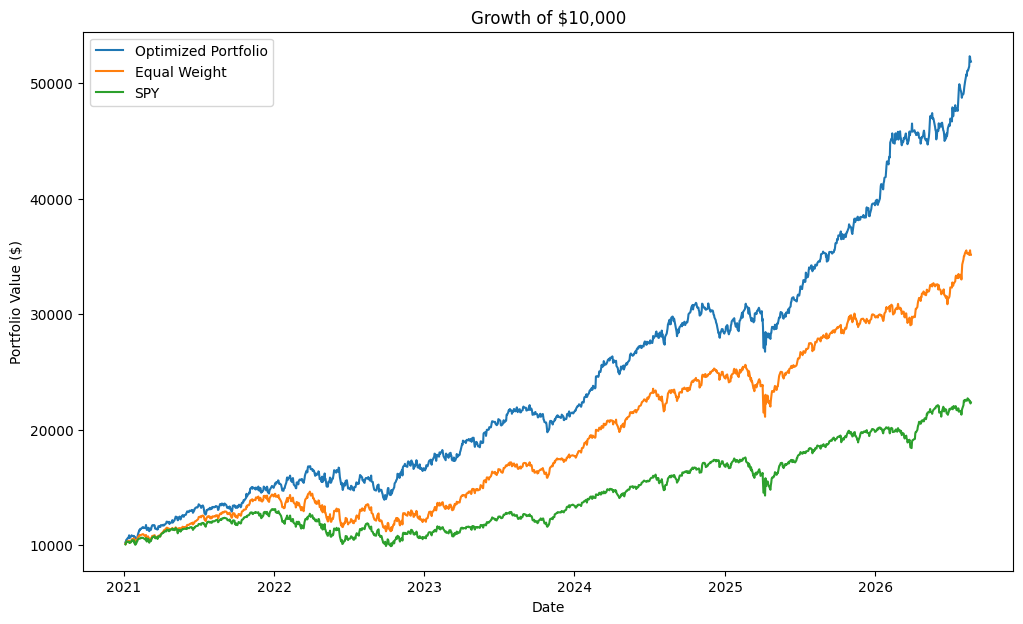

In [856]:
plt.figure(figsize=(12,7))

plt.plot(cumulative_wealth.index,
         cumulative_wealth["Optimized"],
         label="Optimized Portfolio")

plt.plot(cumulative_wealth.index,
         cumulative_wealth["Equal Weight"],
         label="Equal Weight")

plt.plot(cumulative_wealth.index,
         cumulative_wealth["SPY"],
         label="SPY")

plt.title("Growth of $10,000")

plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")

plt.legend()

plt.show()

In [857]:
# Comapring annualized return, volatility, and Sharpe

annual_returns_comparison = (
    comparison_returns.mean() * 252
)

annual_volatility_comparison = (
    comparison_returns.std() * np.sqrt(252)
)

sharpe_comparison = (
    annual_returns_comparison / annual_volatility_comparison
)

In [858]:
performance_summary = pd.DataFrame({
    "Annual Return": annual_returns_comparison,
    "Annual Volatility": annual_volatility_comparison,
    "Sharpe Ratio": sharpe_comparison
})

performance_summary

,Annual Return,Annual Volatility,Sharpe Ratio
Optimized,0.307201,0.165587,1.855224
Equal Weight,0.239176,0.173862,1.375663
SPY,0.157453,0.167525,0.939879


In [859]:
display_summary = performance_summary.copy()

display_summary["Annual Return"] *= 100
display_summary["Annual Volatility"] *= 100

display_summary.round(2)

,Annual Return,Annual Volatility,Sharpe Ratio
Optimized,30.72,16.56,1.86
Equal Weight,23.92,17.39,1.38
SPY,15.75,16.75,0.94


In [860]:
# Calculating the Beta
portfolio_market_covariance = (
    comparison_returns['Optimized'].cov(comparison_returns["SPY"])
)

market_variance = (comparison_returns["SPY"].var())

portfolio_beta = (portfolio_market_covariance / market_variance)

print(f"Portfolio Beta: "
      f"{portfolio_beta:.3f}")

Portfolio Beta: 0.721


In [861]:
portfolio_alpha = (
    annual_returns_comparison["Optimized"] - portfolio_beta * annual_returns_comparison["SPY"]
)

print(f"Annualized Alpha: "
      f"{portfolio_alpha:.2%}")

Annualized Alpha: 19.37%


In [862]:
from scipy.stats import linregress

x = comparison_returns["SPY"]
y = comparison_returns["Optimized"]

regression = linregress(x, y)

daily_alpha = regression.intercept
regression_beta = regression.slope
r_squared = regression.rvalue **2 

print(f"Regression Beta: {regression_beta:.3f}")
print(f"Daily Alpha: {daily_alpha:.4%}")
print(f"R-Squared: {r_squared:.3f}")

Regression Beta: 0.721
Daily Alpha: 0.0769%
R-Squared: 0.532


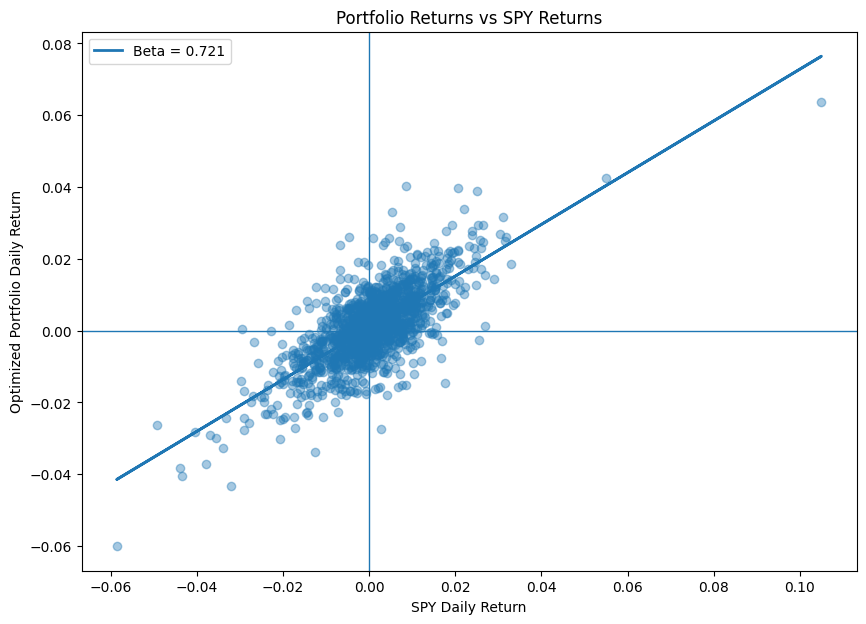

In [863]:
plt.figure(figsize=(10, 7))
plt.scatter(x, y, alpha=0.4)

regression_line = (daily_alpha + regression_beta * x)

plt.plot(x, 
         regression_line,
         linewidth=2,
         label=f"Beta = {regression_beta:.3f}")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("SPY Daily Return")
plt.ylabel("Optimized Portfolio Daily Return")
plt.title("Portfolio Returns vs SPY Returns")

plt.legend()
plt.show()

In [864]:
annualized_regression_alpha = (daily_alpha * 252)
print(f"Annualized Regression Alpha: " f"{annualized_regression_alpha:.2%}")

Annualized Regression Alpha: 19.37%


### OUT OF SAMPLE BACKTESTING

In [865]:
train_returns = returns.loc[:"2024-12-31"]
test_returns = returns.loc["2025-01-01":]

print("Training shape:", train_returns.shape)
print("Testing shape:", test_returns.shape)

Training shape: (1004, 8)
Testing shape: (410, 8)


In [866]:
train_annual_returns = (
    train_returns.mean() * 252
)

train_cov_matrix = (
    train_returns.cov() * 252
)

In [867]:
def train_portfolio_volatility(weights):
    return np.sqrt(weights.T @ train_cov_matrix @ weights)

In [868]:
def train_negative_sharpe(weights):
    portfolio_return = (weights @ train_annual_returns)

    portfolio_volatility = np.sqrt(weights.T @ train_cov_matrix @ weights)

    sharpe =(portfolio_return / portfolio_volatility )

    return -sharpe

In [869]:
oos_result = minimize(
    train_negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds = bounds,
    constraints=frontier_constraints
)

print(oos_result.success)
print(oos_result.message)

True
Optimization terminated successfully


In [870]:
oos_weights = oos_result.x

In [871]:
oos_allocation = pd.Series(
    oos_weights, 
    index=train_annual_returns.index
)
(oos_allocation * 100).round(2)

Ticker
AAPL      0.0
AMZN      0.0
JNJ       0.0
JPM       0.0
MSFT      0.0
NVDA    100.0
PG        0.0
XOM       0.0
dtype: float64

In [872]:
oos_portfolio_returns = (
    test_returns @ oos_weights
)

oos_portfolio_returns.name = "Optimized OOS"

In [873]:
oos_equal_weight_returns = (
    test_returns @ equal_weights
)

oos_equal_weight_returns.name = "Equal Weight"

In [874]:
oos_spy_returns =  benchmark_returns.loc[oos_portfolio_returns.index]

In [875]:
oos_comparison = pd.concat([oos_portfolio_returns,
                            oos_equal_weight_returns,
                            oos_spy_returns],
                            axis=1).dropna()

oos_comparison.columns = [
    "Optimized OOS",
    "Equal Weight",
    "SPY"
]

oos_comparison.head()

,Optimized OOS,Equal Weight,SPY
Date,,,
2025-01-02,0.029935,-0.001845,-0.002457
2025-01-03,0.044538,0.010850,0.012503
2025-01-06,0.034332,0.003732,0.005761
2025-01-07,-0.062170,-0.008659,-0.011304
2025-01-08,-0.000214,-0.003992,0.001461


In [876]:
oos_annual_returns = (oos_comparison.mean() * 252)

In [877]:
oos_annual_volatility = (oos_comparison.std() * np.sqrt(252))

In [878]:
oos_sharpe = (oos_annual_returns / oos_annual_volatility)

In [879]:
oos_summary = pd.DataFrame({
    "Annual Return": oos_annual_returns,
    "Annual Volatility": oos_annual_volatility,
    "Sharpe Ratio": oos_sharpe
})

display_oos_summary = oos_summary.copy()

display_oos_summary["Annual Return"] *=100
display_oos_summary["Annual Volatility"] *=100

display_oos_summary.round(2)

,Annual Return,Annual Volatility,Sharpe Ratio
Optimized OOS,39.24,45.34,0.87
Equal Weight,23.49,15.80,1.49
SPY,18.98,17.43,1.09


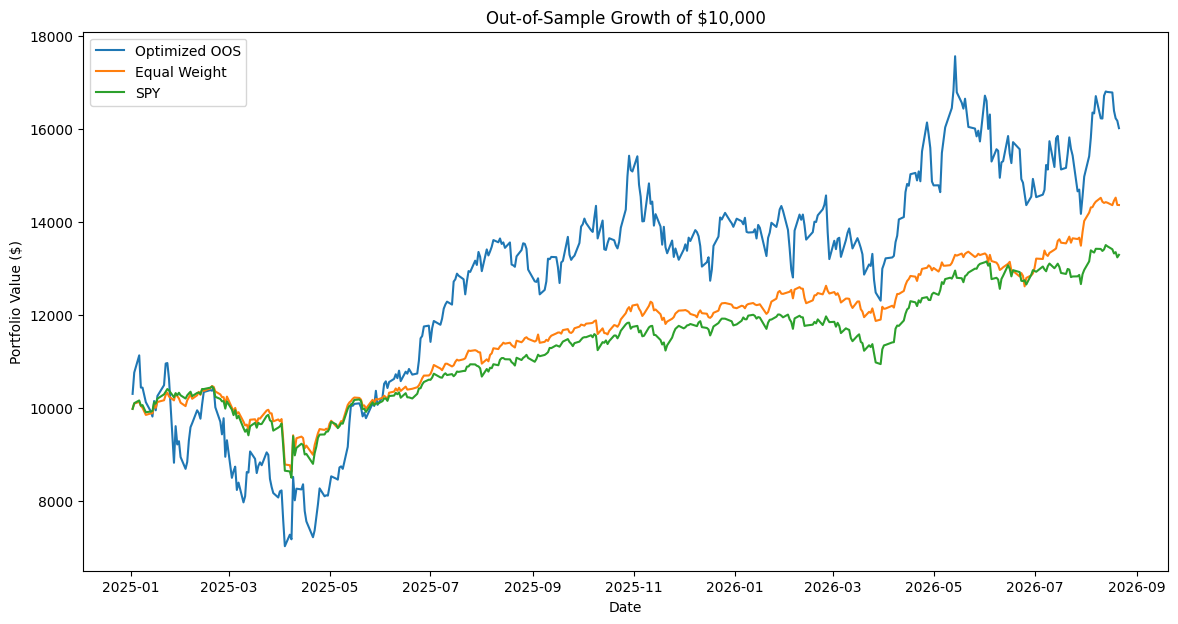

In [880]:
oos_initial_investment = 10000

oos_wealth = (oos_initial_investment * (1+ oos_comparison).cumprod())

plt.figure(figsize=(14, 7))

plt.plot(oos_wealth.index,
         oos_wealth["Optimized OOS"],
         label="Optimized OOS")

plt.plot(
    oos_wealth.index,
    oos_wealth["Equal Weight"],
    label = "Equal Weight"
)

plt.plot(oos_wealth.index,
         oos_wealth["SPY"],
         label="SPY")

plt.title("Out-of-Sample Growth of $10,000")

plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")

plt.legend()
plt.show()

In [881]:
oos_allocation_percent  = (
    pd.Series(oos_weights, index=train_returns.columns) * 100
)

print(oos_allocation_percent.sort_values(ascending=False).round(2))

Ticker
NVDA    100.0
XOM       0.0
JPM       0.0
PG        0.0
JNJ       0.0
MSFT      0.0
AMZN      0.0
AAPL      0.0
dtype: float64


In [882]:
# Insepcting Concentration risk
oos_allocation_percent = (
    pd.Series(
        oos_weights,
        index = train_returns.columns
    ) * 100
)

oos_allocation_percent.sort_values(ascending=False).round(2)

Ticker
NVDA    100.0
XOM       0.0
JPM       0.0
PG        0.0
JNJ       0.0
MSFT      0.0
AMZN      0.0
AAPL      0.0
dtype: float64

In [883]:
largest_weight = (oos_allocation_percent.max())

print(f"Largest Position: " f"{largest_weight:.2f}%")

Largest Position: 100.00%


In [884]:
top_3_weight = (oos_allocation_percent.sort_values(ascending=False).head(3).sum())

print(f"Top 3 Concentration: " f"{top_3_weight:.2f}%")

Top 3 Concentration: 100.00%


In [885]:
constrained_bounds = tuple((0, 0.25)
                           for _ in range(n_assets))


In [886]:
constrained_oos_result = minimize(
    train_negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=constrained_bounds,
    constraints = constraints
)

print(constrained_oos_result.success)
print(constrained_oos_result.message)

True
Optimization terminated successfully


In [887]:
constrained_oos_weights = (constrained_oos_result.x)

In [888]:
constrained_oos_allocation = pd.Series(constrained_oos_weights, 
                                       index=train_returns.columns)

(
    constrained_oos_allocation * 100
).sort_values(ascending=False).round(2)

Ticker
PG      25.00
XOM     25.00
NVDA    25.00
JPM     18.19
JNJ      6.81
AMZN     0.00
MSFT     0.00
AAPL     0.00
dtype: float64

In [889]:
# Applying the same unseen 2025-2026 test period

constrained_oos_returns = (
    test_returns @ constrained_oos_weights
)

constrained_oos_returns.name = ("Constrained Optimized")

In [890]:
constrained_comparison = pd.concat([constrained_oos_returns,
                                    oos_equal_weight_returns,
                                    oos_spy_returns],
                                    axis=1).dropna()

constrained_comparison.columns = [
    "Constrained Optimized",
    "Equal Weight",
    "SPY"
]

In [891]:
constrained_annual_returns = (
    constrained_comparison.mean() * 252
)

constrained_annual_volatility = (
    constrained_comparison.std() * np.sqrt(252)
)

constrained_sharpe = (
    constrained_annual_returns / constrained_annual_volatility
)

In [892]:
constrained_summary = pd.DataFrame({
    "Annual Returns": constrained_annual_returns,

    "Annual Volatility": constrained_annual_volatility,

    "Sharpe Ratio": constrained_sharpe
})

display_constrained = (
    constrained_summary.copy()
)

display_constrained ["Annual Returns"] *= 100

display_constrained["Annual Volatility"] *= 100
display_constrained.round(2)

,Annual Returns,Annual Volatility,Sharpe Ratio
Constrained Optimized,25.19,15.90,1.58
Equal Weight,23.49,15.80,1.49
SPY,18.98,17.43,1.09


In [893]:
# Walk forward backtest
lookback_years = 3
rebalance_frequency = "QE"

In [894]:
rebalance_dates = (
    returns.resample(rebalance_frequency).last().index
)
rebalance_dates[:10]

DatetimeIndex(['2021-03-31', '2021-06-30', '2021-09-30', '2021-12-31',
               '2022-03-31', '2022-06-30', '2022-09-30', '2022-12-31',
               '2023-03-31', '2023-06-30'],
              dtype='datetime64[s]', name='Date', freq='QE-DEC')

In [895]:
first_possible_date = (returns.index.min() + pd.DateOffset(years=lookback_years))

first_possible_date

Timestamp('2024-01-05 00:00:00')

In [896]:
rebalance_dates = rebalance_dates[rebalance_dates >= first_possible_date]
rebalance_dates

DatetimeIndex(['2024-03-31', '2024-06-30', '2024-09-30', '2024-12-31',
               '2025-03-31', '2025-06-30', '2025-09-30', '2025-12-31',
               '2026-03-31', '2026-06-30', '2026-09-30'],
              dtype='datetime64[s]', name='Date', freq='QE-DEC')

In [897]:
actual_rebalance_dates = []

for date in rebalance_dates:
    valid_date = returns.index[returns.index <= date]

    actual_rebalance_dates.append(valid_date[-1])

actual_rebalance_dates = pd.DatetimeIndex(actual_rebalance_dates)

actual_rebalance_dates

DatetimeIndex(['2024-03-28', '2024-06-28', '2024-09-30', '2024-12-31',
               '2025-03-31', '2025-06-30', '2025-09-30', '2025-12-31',
               '2026-03-31', '2026-06-30', '2026-08-21'],
              dtype='datetime64[s]', freq=None)

In [898]:
rebalance_date = actual_rebalance_dates[0]
rebalance_date

Timestamp('2024-03-28 00:00:00')

In [899]:
lookback_start = ( rebalance_date - pd.DateOffset(years=lookback_years))

lookback_start

Timestamp('2021-03-28 00:00:00')

In [900]:
rolling_window = returns.loc[lookback_start:rebalance_date]

rolling_window.shape

(756, 8)

In [901]:
rolling_annual_returns = (rolling_window.mean() * 252)
rolling_cov_matrix = (rolling_window.cov() * 252)

In [902]:
# Definig the max-Sharpe objective using only this rolling window
def rolling_negative_sharpe(weights):
    portfolio_return = (weights @ rolling_annual_returns)

    portfolio_volatility = np.sqrt(weights.T @ rolling_cov_matrix @ weights)

    sharpe = (portfolio_return / portfolio_volatility)

    return -sharpe

In [903]:
rolling_result = minimize(rolling_negative_sharpe,
                          initial_weights,
                          method ="SLSQP",
                          bounds=constrained_bounds,
                          constraints =constraints)

In [904]:
print(rolling_result.success)
print(rolling_result.message)

True
Optimization terminated successfully


In [905]:
first_rolling_weights = pd.Series(rolling_result.x,
                                  index=returns.columns)

(first_rolling_weights * 100).sort_values(ascending=False).round(2)

Ticker
XOM     25.00
NVDA    25.00
PG      25.00
JNJ     21.61
MSFT     2.74
JPM      0.64
AMZN     0.00
AAPL     0.00
dtype: float64

In [906]:
# Sending this portfolio into the future 
next_rebalance_date = actual_rebalance_dates[1]
next_rebalance_date

Timestamp('2024-06-28 00:00:00')

In [907]:
# Getting the future holding-period returns:
holding_period = returns.loc[(returns.index > rebalance_date) & (returns.index <= next_rebalance_date)]

holding_period.shape

(63, 8)

In [908]:
# Applying the frozen March weight
first_period_portfolio_returns = (holding_period @ first_rolling_weights)

first_period_portfolio_returns.head()

Date
2024-04-01   -0.001294
2024-04-02    0.002084
2024-04-03   -0.013041
2024-04-04   -0.011519
2024-04-05    0.011016
dtype: float64

In [909]:
# Calculating the compunded holding-period return
first_period_total_return = (
    (1 + first_period_portfolio_returns).prod() - 1
)

print(f"First OOS Holding Period Return: "
      f"{first_period_total_return:.2%}")

First OOS Holding Period Return: 8.29%


### That means that $10,000 would have become: $10,829 during that quarter

In [910]:
# we can verify by
first_period_ending_value = ( 10000 * (1 + first_period_total_return))

print(f"$10000 Ending Value: "
      f"${first_period_ending_value:,.2f}")

$10000 Ending Value: $10,829.25


In [911]:
# Here we want to repeat what we just did manually for every quarter
walk_forward_returns = []
walk_forward_weights = {}

In [912]:
# Creating loop
for i in range(len(actual_rebalance_dates)-1):

    # Current and next rebalance date
    rebalance_date = actual_rebalance_dates[i]
    next_rebalance_date = actual_rebalance_dates[i+1]

    # 3-year rolling lookback
    lookback_start = (
        rebalance_date - pd.DateOffset(years=lookback_years)
    )

    rolling_window = returns.loc[lookback_start:rebalance_date]

    # Estimate expected returns and covariance
    rolling_annual_returns = (rolling_window.mean() * 252)

    rolling_cov_matrix = (rolling_window.cov() * 252)

    # Objective function
    def rolling_negative_sharpe(weights):
        portfolio_return = (weights @ rolling_annual_returns)

        portfolio_volatility = np.sqrt(weights.T @ rolling_cov_matrix @ weights)

        return -(portfolio_return / portfolio_volatility)
    

    # Optimixe
    rolling_result = minimize(rolling_negative_sharpe,
                              initial_weights,
                              method="SLSQP",
                              bounds=constrained_bounds,
                              constraints = constraints)
    

    # Optimized weights
    weights = rolling_result.x
    
    # Save weights
    walk_forward_weights[rebalance_date] = weights

    # Future holding period
    holding_period = returns.loc[(returns.index > rebalance_date) & (returns.index <= next_rebalance_date)]

    # Realized portfolio returns
    period_returns = (holding_period @ weights)

    walk_forward_returns.append(period_returns)

In [913]:
# so far walk_forward_returns is a list containing separate quarterly return series so now we are turning them into one continuous return series

walk_forward_returns = pd.concat(walk_forward_returns)
walk_forward_returns.name = "Walk Forward"
walk_forward_returns.head()

Date
2024-04-01   -0.001294
2024-04-02    0.002084
2024-04-03   -0.013041
2024-04-04   -0.011519
2024-04-05    0.011016
Name: Walk Forward, dtype: float64

In [914]:
walk_forward_returns.tail()

Date
2026-08-17    0.001381
2026-08-18    0.009122
2026-08-19   -0.003507
2026-08-20   -0.010546
2026-08-21    0.001241
Name: Walk Forward, dtype: float64

In [915]:
walk_forward_returns.shape

(601,)

In [916]:
# Converting the stored weights into a table
walk_forward_weights_df = pd.DataFrame.from_dict(
    walk_forward_weights,
    orient="index",
    columns=returns.columns
)

walk_forward_weights_df.index.name = "Rebalance Date"
walk_forward_weights_df

Ticker,AAPL,AMZN,JNJ,JPM,MSFT,NVDA,PG,XOM
Rebalance Date,,,,,,,,
2024-03-28,4.946508e-17,7.878897e-16,0.216118,0.006443,2.743886e-02,0.250000,0.250000,0.250000
2024-06-28,3.231125e-16,0.000000e+00,0.140769,0.073385,3.584611e-02,0.250000,0.250000,0.250000
2024-09-30,6.222830e-17,1.145871e-16,0.250000,0.000000,0.000000e+00,0.250000,0.250000,0.250000
2024-12-31,4.006398e-16,0.000000e+00,0.000000,0.250000,8.332430e-17,0.250000,0.250000,0.250000
2025-03-31,2.948143e-16,2.030499e-17,0.002570,0.250000,0.000000e+00,0.247430,0.250000,0.250000
2025-06-30,0.000000e+00,0.000000e+00,0.114027,0.250000,1.558435e-02,0.250000,0.250000,0.120389
2025-09-30,1.244983e-17,0.000000e+00,0.250000,0.250000,5.375332e-17,0.250000,0.220398,0.029602
2025-12-31,3.877263e-02,5.917295e-02,0.250000,0.250000,5.603365e-17,0.250000,0.121353,0.030701
2026-03-31,3.941791e-17,3.218348e-02,0.250000,0.222131,0.000000e+00,0.194165,0.105890,0.195630


In [917]:
(walk_forward_weights_df * 100).round(2)


Ticker,AAPL,AMZN,JNJ,JPM,MSFT,NVDA,PG,XOM
Rebalance Date,,,,,,,,
2024-03-28,0.00,0.00,21.61,0.64,2.74,25.00,25.00,25.00
2024-06-28,0.00,0.00,14.08,7.34,3.58,25.00,25.00,25.00
2024-09-30,0.00,0.00,25.00,0.00,0.00,25.00,25.00,25.00
2024-12-31,0.00,0.00,0.00,25.00,0.00,25.00,25.00,25.00
2025-03-31,0.00,0.00,0.26,25.00,0.00,24.74,25.00,25.00
2025-06-30,0.00,0.00,11.40,25.00,1.56,25.00,25.00,12.04
2025-09-30,0.00,0.00,25.00,25.00,0.00,25.00,22.04,2.96
2025-12-31,3.88,5.92,25.00,25.00,0.00,25.00,12.14,3.07
2026-03-31,0.00,3.22,25.00,22.21,0.00,19.42,10.59,19.56


### This is where our project starts becoming genuinely dynamics cause earlier we had the weights = one fixed vector but now we have wt, meaning portfolio weights depend on time

In [918]:
print("Number of rebalance periods:", len(walk_forward_weights_df))
print("Number of daily OOS observations:", len(walk_forward_returns))
print("Start:",walk_forward_returns.index.min())
print("End:", walk_forward_returns.index.max())

Number of rebalance periods: 10
Number of daily OOS observations: 601
Start: 2024-04-01 00:00:00
End: 2026-08-21 00:00:00


In [919]:
# Budilding that walk-forward wealth curve, starting with $10000

initial_investment= 10000

walk_forward_wealth = (initial_investment * (1 + walk_forward_returns).cumprod())
print(f"Walk-Forward Final Value: " f"${walk_forward_wealth.iloc[-1]:,.2f}")

print(f"Total Return:" f"{walk_forward_wealth.iloc[-1] / initial_investment - 1:.2%}")


Walk-Forward Final Value: $15,944.77
Total Return:59.45%


In [920]:
# Creating fair benchmarks by creating one aligned DataFrame
walk_forward_comparison = pd.concat([walk_forward_returns.rename("Walk Forward"),
                                     equal_weight_daily_returns.rename("Equal Weight"),
                                     benchmark_returns.rename("SPY")],
                                     axis =1).dropna()
walk_forward_comparison.head()

/var/folders/qb/y15c8p3j2v5122w7hy2sn6g80000gn/T/ipykernel_23060/3256808759.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  walk_forward_comparison = pd.concat([walk_forward_returns.rename("Walk Forward"),


,Walk Forward,Equal Weight,SPY
Date,,,
2024-04-01,-0.001294,-0.001147,-0.001740
2024-04-02,0.002084,-0.000901,-0.006358
2024-04-03,-0.013041,-0.005708,0.001099
2024-04-04,-0.011519,-0.009823,-0.012206
2024-04-05,0.011016,0.012734,0.010447


In [921]:
print(walk_forward_comparison.index.min())
print(walk_forward_comparison.index.max())
print(walk_forward_comparison.shape)

2024-04-01 00:00:00
2026-08-21 00:00:00
(601, 3)


In [922]:
# Calculating the wealth for all three
comparison_wealth = (initial_investment * (1 + walk_forward_comparison).cumprod())
comparison_wealth.tail()

,Walk Forward,Equal Weight,SPY
Date,,,
2026-08-17,16005.378781,16873.814662,15170.310952
2026-08-18,16151.387016,16987.733555,15067.824017
2026-08-19,16094.742690,17063.989502,15099.433862
2026-08-20,15925.006628,16879.717007,14972.600227
2026-08-21,15944.772160,16877.792780,15033.857034


In [923]:
print("Final Values")
print("-" * 26)

for column in comparison_wealth.columns:
    print(f"{column}: " f"${comparison_wealth[column].iloc[-1]:,.2f}")

Final Values
--------------------------
Walk Forward: $15,944.77
Equal Weight: $16,877.79
SPY: $15,033.86


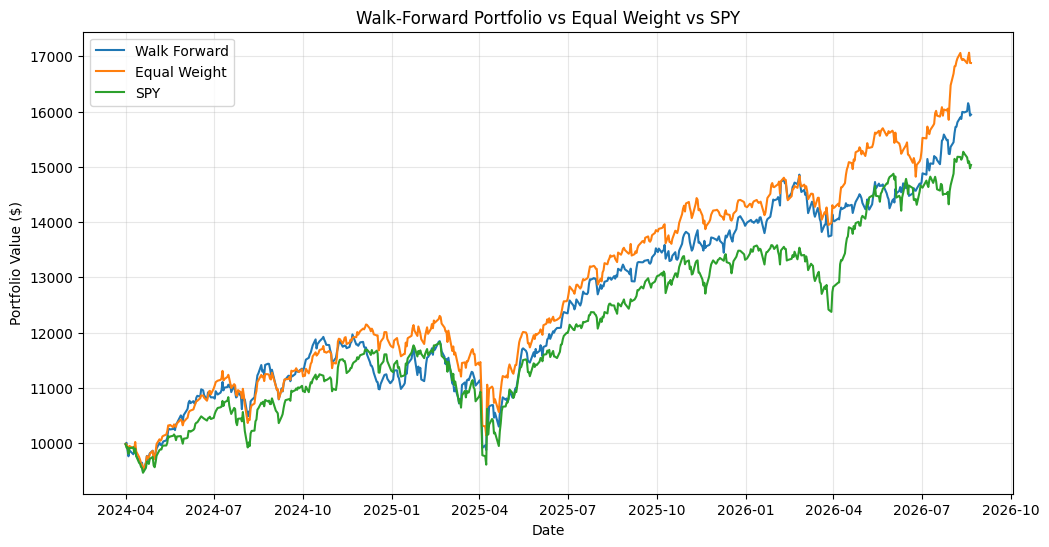

In [924]:
plt.figure(figsize=(12, 6))

for column in comparison_wealth.columns:
    plt.plot(comparison_wealth.index,
             comparison_wealth[column],
             label=column)
    
plt.title("Walk-Forward Portfolio vs Equal Weight vs SPY")

plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha =0.3)

plt.show()

In [925]:
# Calculate annualized performance

def calculate_performance(return_series):

    annual_return = (return_series.mean() * 252)

    annual_volatility = (return_series.std() * np.sqrt(252))

    sharpe_ratio = (
        annual_return / annual_volatility)
    
    return (annual_return,
            annual_volatility,
            sharpe_ratio)

In [926]:
performance_results = {}

for column in walk_forward_comparison.columns:
    annual_return,annual_volatility, sharpe = (calculate_performance(walk_forward_comparison[column])) 

    performance_results[column] = {
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe
    }

In [927]:
performance_df = pd.DataFrame(performance_results).T
performance_df

,Annual Return,Annual Volatility,Sharpe Ratio
Walk Forward,0.207942,0.156722,1.326822
Equal Weight,0.230546,0.148639,1.551044
SPY,0.183962,0.161555,1.138699


In [928]:
display_performance = performance_df.copy()

display_performance[['Annual Return', "Annual Volatility"]] *= 100

display_performance.round(2)

,Annual Return,Annual Volatility,Sharpe Ratio
Walk Forward,20.79,15.67,1.33
Equal Weight,23.05,14.86,1.55
SPY,18.40,16.16,1.14


In [929]:
# Lets make the backtest more realistic: TURNOVER
walk_forward_weights_df

Ticker,AAPL,AMZN,JNJ,JPM,MSFT,NVDA,PG,XOM
Rebalance Date,,,,,,,,
2024-03-28,4.946508e-17,7.878897e-16,0.216118,0.006443,2.743886e-02,0.250000,0.250000,0.250000
2024-06-28,3.231125e-16,0.000000e+00,0.140769,0.073385,3.584611e-02,0.250000,0.250000,0.250000
2024-09-30,6.222830e-17,1.145871e-16,0.250000,0.000000,0.000000e+00,0.250000,0.250000,0.250000
2024-12-31,4.006398e-16,0.000000e+00,0.000000,0.250000,8.332430e-17,0.250000,0.250000,0.250000
2025-03-31,2.948143e-16,2.030499e-17,0.002570,0.250000,0.000000e+00,0.247430,0.250000,0.250000
2025-06-30,0.000000e+00,0.000000e+00,0.114027,0.250000,1.558435e-02,0.250000,0.250000,0.120389
2025-09-30,1.244983e-17,0.000000e+00,0.250000,0.250000,5.375332e-17,0.250000,0.220398,0.029602
2025-12-31,3.877263e-02,5.917295e-02,0.250000,0.250000,5.603365e-17,0.250000,0.121353,0.030701
2026-03-31,3.941791e-17,3.218348e-02,0.250000,0.222131,0.000000e+00,0.194165,0.105890,0.195630


In [930]:
weight_changes = (walk_forward_weights_df.diff())    # it helps to calculate wt - wt-1
weight_changes

Ticker,AAPL,AMZN,JNJ,JPM,MSFT,NVDA,PG,XOM
Rebalance Date,,,,,,,,
2024-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-06-28,2.736474e-16,-7.878897e-16,-7.534958e-02,6.694234e-02,8.407245e-03,2.775558e-17,6.106227e-16,0.000000e+00
2024-09-30,-2.608842e-16,1.145871e-16,1.092312e-01,-7.338509e-02,-3.584611e-02,-1.665335e-16,0.000000e+00,0.000000e+00
2024-12-31,3.384115e-16,-1.145871e-16,-2.500000e-01,2.500000e-01,8.332430e-17,2.220446e-16,0.000000e+00,-2.220446e-16
2025-03-31,-1.058256e-16,2.030499e-17,2.570249e-03,-5.551115e-17,-8.332430e-17,-2.570249e-03,-1.110223e-16,2.220446e-16
2025-06-30,-2.948143e-16,-2.030499e-17,1.114565e-01,5.551115e-17,1.558435e-02,2.570249e-03,5.551115e-17,-1.296111e-01
2025-09-30,1.244983e-17,0.000000e+00,1.359733e-01,-1.942890e-16,-1.558435e-02,8.326673e-17,-2.960161e-02,-9.078730e-02
2025-12-31,3.877263e-02,5.917295e-02,-5.551115e-17,1.942890e-16,2.280322e-18,-2.775558e-17,-9.904512e-02,1.099545e-03
2026-03-31,-3.877263e-02,-2.698947e-02,5.551115e-17,-2.786852e-02,-5.603365e-17,-5.583457e-02,-1.546342e-02,1.649286e-01


In [931]:
absolute_weight_changes = (weight_changes.abs())
absolute_weight_changes

Ticker,AAPL,AMZN,JNJ,JPM,MSFT,NVDA,PG,XOM
Rebalance Date,,,,,,,,
2024-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-06-28,2.736474e-16,7.878897e-16,7.534958e-02,6.694234e-02,8.407245e-03,2.775558e-17,6.106227e-16,0.000000e+00
2024-09-30,2.608842e-16,1.145871e-16,1.092312e-01,7.338509e-02,3.584611e-02,1.665335e-16,0.000000e+00,0.000000e+00
2024-12-31,3.384115e-16,1.145871e-16,2.500000e-01,2.500000e-01,8.332430e-17,2.220446e-16,0.000000e+00,2.220446e-16
2025-03-31,1.058256e-16,2.030499e-17,2.570249e-03,5.551115e-17,8.332430e-17,2.570249e-03,1.110223e-16,2.220446e-16
2025-06-30,2.948143e-16,2.030499e-17,1.114565e-01,5.551115e-17,1.558435e-02,2.570249e-03,5.551115e-17,1.296111e-01
2025-09-30,1.244983e-17,0.000000e+00,1.359733e-01,1.942890e-16,1.558435e-02,8.326673e-17,2.960161e-02,9.078730e-02
2025-12-31,3.877263e-02,5.917295e-02,5.551115e-17,1.942890e-16,2.280322e-18,2.775558e-17,9.904512e-02,1.099545e-03
2026-03-31,3.877263e-02,2.698947e-02,5.551115e-17,2.786852e-02,5.603365e-17,5.583457e-02,1.546342e-02,1.649286e-01


In [932]:
turnover = (absolute_weight_changes.sum(axis=1) / 2)
turnover.name = "Turnover"
turnover

Rebalance Date
2024-03-28    0.000000
2024-06-28    0.075350
2024-09-30    0.109231
2024-12-31    0.250000
2025-03-31    0.002570
2025-06-30    0.129611
2025-09-30    0.135973
2025-12-31    0.099045
2026-03-31    0.164929
2026-06-30    0.062712
Name: Turnover, dtype: float64

In [933]:
turnover_percent = turnover * 100
turnover_percent

Rebalance Date
2024-03-28     0.000000
2024-06-28     7.534958
2024-09-30    10.923120
2024-12-31    25.000000
2025-03-31     0.257025
2025-06-30    12.961109
2025-09-30    13.597326
2025-12-31     9.904512
2026-03-31    16.492860
2026-06-30     6.271212
Name: Turnover, dtype: float64

In [934]:
average_turnover = turnover.mean()
print(f"Average Quarterly Turnover: " f"{average_turnover:.2%}")

Average Quarterly Turnover: 10.29%


In [935]:
total_turnover = turnover.sum()

print(f"Total Turnover: " f"{total_turnover:.2%}")

Total Turnover: 102.94%


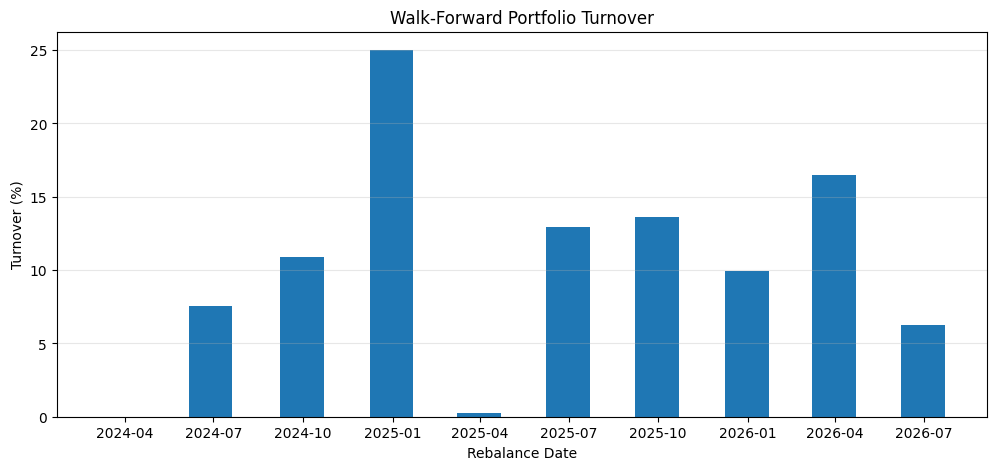

In [936]:
# Checking whether the optimizer is stable or jumping around
plt.figure(figsize=(12, 5))

plt.bar(turnover.index,
        turnover * 100,
        width=45)

plt.title("Walk-Forward Portfolio Turnover")

plt.xlabel("Rebalance Date")
plt.ylabel("Turnover (%)")

plt.grid(axis="y",
         alpha=0.3)

plt.show()

In [937]:
target_turnover = (walk_forward_weights_df.diff().abs().sum(axis=1) /2)
target_turnover.iloc[0] = np.nan
target_turnover

Rebalance Date
2024-03-28         NaN
2024-06-28    0.075350
2024-09-30    0.109231
2024-12-31    0.250000
2025-03-31    0.002570
2025-06-30    0.129611
2025-09-30    0.135973
2025-12-31    0.099045
2026-03-31    0.164929
2026-06-30    0.062712
dtype: float64

In [938]:
(target_turnover * 100 ).round(2)

Rebalance Date
2024-03-28      NaN
2024-06-28     7.53
2024-09-30    10.92
2024-12-31    25.00
2025-03-31     0.26
2025-06-30    12.96
2025-09-30    13.60
2025-12-31     9.90
2026-03-31    16.49
2026-06-30     6.27
dtype: float64

In [939]:
average_target_turnover = (target_turnover.iloc[1:].mean())
total_target_turnover = (target_turnover.iloc[1:].sum())

print(f"Average Turnover per Rebalance: " f"{average_target_turnover:.2%}")
print(f"Total Turnover: " f"{total_target_turnover:.2%}")

Average Turnover per Rebalance: 11.44%
Total Turnover: 102.94%


In [940]:
rebalance_date = actual_rebalance_dates[0]
next_rebalance_date = actual_rebalance_dates[1]

print("Start:", rebalance_date)
print("Next Rebalance:", next_rebalance_date)

Start: 2024-03-28 00:00:00
Next Rebalance: 2024-06-28 00:00:00


In [941]:
start_weights = walk_forward_weights_df.loc[rebalance_date]
print((start_weights * 100).round(2))

Ticker
AAPL     0.00
AMZN     0.00
JNJ     21.61
JPM      0.64
MSFT     2.74
NVDA    25.00
PG      25.00
XOM     25.00
Name: 2024-03-28 00:00:00, dtype: float64


In [942]:
holding_asset_returns = returns.loc[(returns.index > rebalance_date) & (returns.index <= next_rebalance_date)]

In [943]:
asset_period_returns = ((1 + holding_asset_returns).prod() -1 )
print((asset_period_returns * 100).round(2))

Ticker
AAPL    22.99
AMZN     7.13
JNJ     -6.86
JPM      1.57
MSFT     6.43
NVDA    36.74
PG       2.30
XOM     -0.16
dtype: float64


In [944]:
# Calculating every position's ending value
ending_position_values = (start_weights * (1 + asset_period_returns))
ending_position_values

Ticker
AAPL    6.083780e-17
AMZN    8.441051e-16
JNJ     2.012972e-01
JPM     6.543746e-03
MSFT    2.920213e-02
NVDA    3.418426e-01
PG      2.557549e-01
XOM     2.496023e-01
dtype: float64

In [945]:
drifted_weights = (ending_position_values / ending_position_values.sum())
print((drifted_weights * 100 ).round(2))
print("\nTotal:", drifted_weights.sum())

Ticker
AAPL     0.00
AMZN     0.00
JNJ     18.57
JPM      0.60
MSFT     2.69
NVDA    31.53
PG      23.59
XOM     23.02
dtype: float64

Total: 1.0


In [946]:
# Get the new june target weights
new_target_weights = walk_forward_weights_df.loc[next_rebalance_date]

print("Drifted Weights Before Rebalanceng:")
print((drifted_weights * 100).round(2))

print("\nNew Target Weights:")
print((new_target_weights * 100).round(2))

Drifted Weights Before Rebalanceng:
Ticker
AAPL     0.00
AMZN     0.00
JNJ     18.57
JPM      0.60
MSFT     2.69
NVDA    31.53
PG      23.59
XOM     23.02
dtype: float64

New Target Weights:
Ticker
AAPL     0.00
AMZN     0.00
JNJ     14.08
JPM      7.34
MSFT     3.58
NVDA    25.00
PG      25.00
XOM     25.00
Name: 2024-06-28 00:00:00, dtype: float64


In [947]:
# Lets calculate what we need to buy/sell
required_trades = (new_target_weights - drifted_weights)

print("Required Trades:")
print((required_trades * 100).round(2))

print("Net trades:", required_trades.sum())

Required Trades:
Ticker
AAPL    0.00
AMZN   -0.00
JNJ    -4.49
JPM     6.73
MSFT    0.89
NVDA   -6.53
PG      1.41
XOM     1.98
dtype: float64
Net trades: -9.367506770274758e-17


In [948]:
# Calculate our first drift-adjusted turnover
first_drift_turnover = (required_trades.abs().sum() / 2)

print(f"Drift-Adjusted Turnover: "
      f"{first_drift_turnover:.2%}")


Drift-Adjusted Turnover: 11.02%


In [949]:
# Lets compare it with our siimpler calculation
print(f"Target-to-Target Turnover: "
      f"{target_turnover.loc[next_rebalance_date]:.2%}")

print(f"Drift-Adjusted Turnover:"
      f"{first_drift_turnover:.2%}")

Target-to-Target Turnover: 7.53%
Drift-Adjusted Turnover:11.02%


In [950]:
# Creating a place to store turnover
drift_adjusted_turnover = {}

In [951]:
weight_dates = walk_forward_weights_df.index
for i in range(len(weight_dates) - 1):

    # Current and next rebalance dates
    current_date = weight_dates[i]
    next_date = weight_dates[i +1]

    # Portfolio weights immediately after currently rebalance
    start_weights = walk_forward_weights_df.loc[current_date]

    # Asset returns during the holding period
    holding_returns = returns.loc[(returns.index > current_date) & (returns.index <= next_date)]

    # Compound each asset's return over the quarter
    asset_period_returns = ((1+ holding_returns).prod() - 1)

    # Let the portfolio weights drift naturally
    ending_position_values = (start_weights * (1 + asset_period_returns))

    drifted_weights = (ending_position_values / ending_position_values.sum())

    # New Optimizer target
    new_target_weights = (walk_forward_weights_df.loc[next_date])

    # Actual trades required
    required_trades = (new_target_weights - drifted_weights)

    # Drifted-adjusted turnover
    turnover_value = (required_trades.abs().sum() / 2)

    # Store using the date when trading occurs
    drift_adjusted_turnover[next_date] = turnover_value



In [952]:
# convert the dictionary into series
drift_adjusted_turnover = pd.Series(drift_adjusted_turnover, name="Drift-Adjusted Turnover")
print((drift_adjusted_turnover * 100).round(2))

print("Number of Rebalance: ", len(drift_adjusted_turnover))

2024-06-28    11.02
2024-09-30    11.28
2024-12-31    26.36
2025-03-31     4.69
2025-06-30    16.83
2025-09-30    12.28
2025-12-31    10.44
2026-03-31    15.28
2026-06-30     3.67
Name: Drift-Adjusted Turnover, dtype: float64
Number of Rebalance:  9


In [953]:
# Comparing two methods
turnover_comparison = pd.concat([
    target_turnover.rename("Target-to-Target"),
    drift_adjusted_turnover
], axis=1).dropna()

print((turnover_comparison * 100).round(2))

            Target-to-Target  Drift-Adjusted Turnover
2024-06-28              7.53                    11.02
2024-09-30             10.92                    11.28
2024-12-31             25.00                    26.36
2025-03-31              0.26                     4.69
2025-06-30             12.96                    16.83
2025-09-30             13.60                    12.28
2025-12-31              9.90                    10.44
2026-03-31             16.49                    15.28
2026-06-30              6.27                     3.67


In [954]:
print("TARGET-TO-TARGET")
print(f"Average: "
      f"{turnover_comparison['Target-to-Target'].mean():.2%}")
print(f"Total:"
      f"{turnover_comparison['Target-to-Target'].sum():.2%}")

print("\nDRIFT-ADJUSTTED")

print(f"Average: "
      f"{turnover_comparison['Drift-Adjusted Turnover'].mean():.2%}")

print(f"Total: " 
      f"{turnover_comparison['Drift-Adjusted Turnover'].sum():.2%}")

TARGET-TO-TARGET
Average: 11.44%
Total:102.94%

DRIFT-ADJUSTTED
Average: 12.43%
Total: 111.85%


In [955]:
current_date = weight_dates[0]
next_date = weight_dates[1]

start_weights = walk_forward_weights_df.loc[current_date]

holding_returns = returns.loc[(returns.index > current_date) & (returns.index <= next_date)]

In [956]:
position_values = start_weights.copy()

In [957]:
asset_growth = (1+ holding_returns).cumprod()

position_values_over_time = (asset_growth * start_weights)

portfolio_value = (position_values_over_time.sum(axis=1))

portfolio_value.head()

Date
2024-04-01    0.998706
2024-04-02    1.000821
2024-04-03    0.987880
2024-04-04    0.976620
2024-04-05    0.987395
dtype: float64

In [958]:
true_period_returns = portfolio_value.pct_change()

In [959]:
true_period_returns.iloc[0] = (portfolio_value.iloc[0] - 1)

true_period_returns.name = "True Buy-and-hold"

In [960]:
old_period_returns = (holding_returns @ start_weights)

comparison = pd.concat([old_period_returns.rename("Fixed Weight"),
                        true_period_returns],axis=1)

comparison.head()

,Fixed Weight,True Buy-and-hold
Date,,
2024-04-01,-0.001294,-0.001294
2024-04-02,0.002084,0.002117
2024-04-03,-0.013041,-0.012930
2024-04-04,-0.011519,-0.011398
2024-04-05,0.011016,0.011033


In [961]:
# Checking the quarter's final return
old_quarter_return = ((1+ old_period_returns).prod()-1)

true_quarter_return = (portfolio_value.iloc[-1] - 1)

print(f"Old Fixed-Weight Return: "
      f"{old_quarter_return:.2%}")

print(f"True Buy-and-Hold Return: "
      f"{true_quarter_return:.2%}")

Old Fixed-Weight Return: 8.29%
True Buy-and-Hold Return: 8.42%


In [962]:
ending_weights_check = (position_values_over_time.iloc[-1] / portfolio_value.iloc[-1])
print("Weights from Buy-and-Hold Simulatioms:")
print((ending_weights_check * 100).round(2))

print("\nPreviously Calculated Drifted Weights:")
print((drifted_weights * 100).round(2))

Weights from Buy-and-Hold Simulatioms:
Ticker
AAPL     0.00
AMZN     0.00
JNJ     18.57
JPM      0.60
MSFT     2.69
NVDA    31.53
PG      23.59
XOM     23.02
Name: 2024-06-28 00:00:00, dtype: float64

Previously Calculated Drifted Weights:
Ticker
AAPL     0.00
AMZN     3.55
JNJ     25.20
JPM     23.97
MSFT     0.00
NVDA    21.52
PG      10.45
XOM     15.31
dtype: float64


In [963]:
first_asset_period_returns = ((1+ holding_returns).prod()-1)

first_drifted_weights = (start_weights * (1 + first_asset_period_returns))

first_drifted_weights = (first_drifted_weights / first_drifted_weights.sum())

print("Buy-and-Hold Ending Weights: ")

print((ending_weights_check * 100).round(2))

print("\nFormula Drifted  Weights:")
print((first_drifted_weights * 100).round(2))

Buy-and-Hold Ending Weights: 
Ticker
AAPL     0.00
AMZN     0.00
JNJ     18.57
JPM      0.60
MSFT     2.69
NVDA    31.53
PG      23.59
XOM     23.02
Name: 2024-06-28 00:00:00, dtype: float64

Formula Drifted  Weights:
Ticker
AAPL     0.00
AMZN     0.00
JNJ     18.57
JPM      0.60
MSFT     2.69
NVDA    31.53
PG      23.59
XOM     23.02
dtype: float64


In [964]:
# Rebuild walk-forward returns correctly
true_walk_forward_returns = []

In [965]:
for i in range(len(weight_dates)):
    current_date = weight_dates[i]

    # Starting target weights
    start_weights = walk_forward_weights_df.loc[current_date]

    # Determine end of holding period
    if i < len(weight_dates) - 1:
        next_date = weight_dates[i+1]

        holding_returns = returns.loc[(returns.index > current_date) & (returns.index <= next_date)]

    else:
        # Final portfolio: hold until end of available date
        holding_returns = returns.loc[returns.index > current_date]


    # Asset growth from $1 invested
    asset_growth = (1 + holding_returns).cumprod()

    # Dollar value of each position
    position_values = asset_growth * start_weights

    # Total portfolio value
    portfolio_value = position_values.sum(axis=1)

    # Convert portfolio value into daily returns
    period_returns = portfolio_value.pct_change()


    # First day's return relative to starting portfolio value = $1
    if len(period_returns) > 0:
        period_returns.iloc[0] = (portfolio_value.iloc[0] - 1)


    true_walk_forward_returns.append(period_returns)

In [966]:
true_walk_forward_returns = pd.concat(true_walk_forward_returns)

true_walk_forward_returns.name = ("True Walk Forward")

print(true_walk_forward_returns.head())
print()

print(true_walk_forward_returns.tail())
print()

print("Observations:", len(true_walk_forward_returns.index))

print("Start:", true_walk_forward_returns.index.min())

print("End:", true_walk_forward_returns.index.max())

print


Date
2024-04-01   -0.001294
2024-04-02    0.002117
2024-04-03   -0.012930
2024-04-04   -0.011398
2024-04-05    0.011033
Name: True Walk Forward, dtype: float64

Date
2026-08-17    0.001519
2026-08-18    0.008890
2026-08-19   -0.003799
2026-08-20   -0.010217
2026-08-21    0.000898
Name: True Walk Forward, dtype: float64

Observations: 601
Start: 2024-04-01 00:00:00
End: 2026-08-21 00:00:00


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [967]:
# Comparing old vs new backtest

backtest_method_comparison = pd.concat([walk_forward_returns.rename("Fixed Weight"),
                                        true_walk_forward_returns.rename("Buy and Hold")], axis=1).dropna()

In [968]:
# Calculate performance

old_return, old_vol, old_sharpe = (calculate_performance(backtest_method_comparison["Fixed Weight"]))

true_return, true_vol, true_sharpe = (calculate_performance(backtest_method_comparison['Buy and Hold']))

print("OLD FIXED-WEIGHT BACKTEST")
print(f"Return: {old_return:.2%}")
print(f"Volatility: {old_vol:.2%}")
print(f"Sharpe: {old_sharpe:.2f}")


print("\nTRUE QUARTERLY BUY-AND-HOLD")
print(f"Return: {true_return:.2%}")
print(f"Volatility: {true_vol:.2%}")
print(f"Sharpe: {true_sharpe:.2f}")

OLD FIXED-WEIGHT BACKTEST
Return: 20.79%
Volatility: 15.67%
Sharpe: 1.33

TRUE QUARTERLY BUY-AND-HOLD
Return: 20.09%
Volatility: 15.64%
Sharpe: 1.28


### Transaction Costs
lets assume transaction of 10 basic points
Remember:   1 bp = 0.01%
therefore, 10bps = 0.10%  = 0.001

if turnover at a rebalance is 11.02%: 0.1102 * 0.001 = 0.0001102

so that rebalance costs approximately 0.011% of portfolio value under our one-way turnover convention


In [969]:
# Setting the transaction cost

transaction_cost_bps = 10

transaction_cost_rate = (transaction_cost_bps / 10000)

print(f"Transaction Cost Rate: "
      f"{transaction_cost_rate:.4%}")

Transaction Cost Rate: 0.1000%


In [970]:
# Calculating cost at every rebalance
rebalance_costs = ( drift_adjusted_turnover * transaction_cost_rate)

print("Transaction Cost by Rebalance:")
print((rebalance_costs * 100).round(4))

Transaction Cost by Rebalance:
2024-06-28    0.0110
2024-09-30    0.0113
2024-12-31    0.0264
2025-03-31    0.0047
2025-06-30    0.0168
2025-09-30    0.0123
2025-12-31    0.0104
2026-03-31    0.0153
2026-06-30    0.0037
Name: Drift-Adjusted Turnover, dtype: float64


In [971]:
# Total approximate cost
total_transaction_cost = (rebalance_costs.sum())

print(f"Total Approximate Transaction Cost: "
      f"{total_transaction_cost:.4%}")

Total Approximate Transaction Cost: 0.1118%


In [972]:
# Creating gross wealth
initial_capital = 10000

gross_wealth = (initial_capital * ( 1 + true_walk_forward_returns).cumprod())

print(f"Gross Ending Wealth: "
      f"${gross_wealth.iloc[-1]:,.2f}")

Gross Ending Wealth: $15,681.83


### This is our realistic quarterly buy-and-hold strategy before trading costs.

In [973]:
# Building a daily transaction-cost series
daily_transaction_costs = pd.Series(0.0, index= true_walk_forward_returns.index)

In [974]:
for date, cost in rebalance_costs.items():
    if date in daily_transaction_costs.index:
        daily_transaction_costs.loc[date] = cost

In [975]:
print(daily_transaction_costs[daily_transaction_costs >0])

Date
2024-06-28    0.000110
2024-09-30    0.000113
2024-12-31    0.000264
2025-03-31    0.000047
2025-06-30    0.000168
2025-09-30    0.000123
2025-12-31    0.000104
2026-03-31    0.000153
2026-06-30    0.000037
dtype: float64


In [976]:
# Calculating the NET wealth correctly
# for each day:  Vt = Vt-1 (1+rt)(1-ct)

net_growth_factor = (1+ true_walk_forward_returns) * (1 - daily_transaction_costs)


In [977]:
net_wealth = (initial_capital * net_growth_factor.cumprod())

print(f"Gross Ending Wealth: "
      f"${gross_wealth.iloc[-1]:,.2f}")

print(f"Net Ending Wealth: "
      f"${net_wealth.iloc[-1]:,.2f}")

print(f"Dollar Cost Impact: " 
      f"${gross_wealth.iloc[-1] - net_wealth.iloc[-1]:,.2f}")

Gross Ending Wealth: $15,681.83
Net Ending Wealth: $15,664.29
Dollar Cost Impact: $17.53


In [978]:
# Calculate actual net daily returns
net_walk_forward_returns = (net_growth_factor - 1)

net_walk_forward_returns.name = ("Net Walk Forward")

In [979]:
gross_return, gross_vol, gross_sharpe = (calculate_performance(true_walk_forward_returns))

net_return, net_vol, net_sharpe = (calculate_performance(net_walk_forward_returns))

In [980]:
print("GROSS STRATEGY")
print(f"Annual Return: {gross_return:.2%}")
print(f"Volatility: {gross_vol:.2%}")
print(f"Sharpe: {gross_sharpe:.2f}")


print("\nNet STRATEGY")
print(f"Annual Return: {net_return:.2%}")
print(f"Volatility: {net_vol:.2%}")
print(f"Sharpe: {net_sharpe:.2f}")

GROSS STRATEGY
Annual Return: 20.09%
Volatility: 15.64%
Sharpe: 1.28

Net STRATEGY
Annual Return: 20.04%
Volatility: 15.64%
Sharpe: 1.28


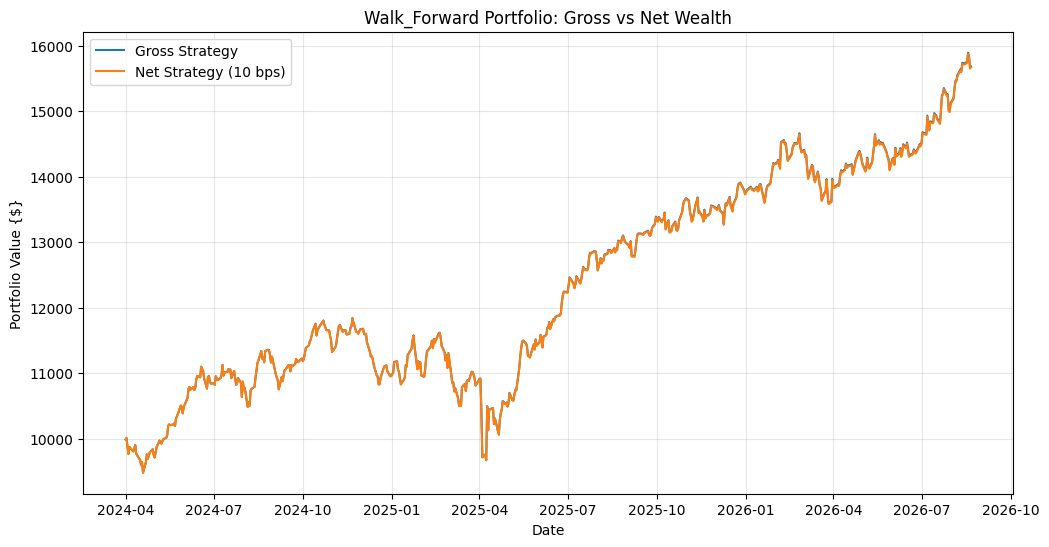

In [981]:
# Plot $10000 gross vs net

plt.figure(figsize=(12, 6))

plt.plot(gross_wealth, label = "Gross Strategy")

plt.plot(net_wealth, label="Net Strategy (10 bps)")

plt.title("Walk_Forward Portfolio: Gross vs Net Wealth")

plt.xlabel("Date")
plt.ylabel("Portfolio Value {$}")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Transaction-cost sensitivity analysis

In [982]:
cost_scenarios_bps = [5, 10, 25]
cost_sensitivity_results = []

In [983]:
for bps in cost_scenarios_bps:
    scenario_cost_rate = bps / 10000

    # Transaction Cost at each rebalance
    scenario_rebalance_costs = (drift_adjusted_turnover * scenario_cost_rate)

    # Daily cost series
    scenario_daily_cost = pd.Series(0.0, index=true_walk_forward_returns.index)

    for date, cost in scenario_rebalance_costs.items():
        if date in scenario_daily_cost.index:
            scenario_daily_cost.loc[date] = cost

    # Net daily growth factor
    scenario_growth_factor = (( 1+ true_walk_forward_returns) * (1 - scenario_daily_cost))

    # Convert growth factor back to returns
    scenario_net_returns = (scenario_growth_factor - 1)

    # Calculate performance 
    scenario_annual_return = (scenario_net_returns.mean() * 252)
    scenario_volatility = (scenario_net_returns.std() * np.sqrt(252))
    scenario_sharpe = (scenario_annual_return / scenario_volatility)

    # Ending wealth
    scenario_wealth = (initial_capital * scenario_growth_factor.cumprod())

    scenario_ending_wealth = (scenario_wealth.iloc[-1])
    

    cost_sensitivity_results.append({
        "Cost (bps)": bps,
        "Annual Return": scenario_annual_return,
        "Volatility": scenario_volatility,
        "Sharpe": scenario_sharpe,
        "Ending Wealth": scenario_ending_wealth
    })

In [984]:
# Converting into a table
cost_sensitivity_df = pd.DataFrame(cost_sensitivity_results)
cost-cost_sensitivity_df

,Cost (bps),Annual Return,Volatility,Sharpe,Ending Wealth
0,-4.999908,-0.200592,-0.156323,-1.282932,-15673.057803
1,-9.999908,-0.200356,-0.156318,-1.281469,-15664.294374
2,-24.999908,-0.199650,-0.156303,-1.277072,-15638.029355


In [985]:
# For Cleaner Display

display_table = cost_sensitivity_df.copy()

display_table["Annual Return"] = (display_table["Annual Return"] * 100)
display_table["Volatility"] = (display_table["Volatility"] * 100)
display_table["Annual Return"] = (display_table["Annual Return"].round(2))
display_table["Volatility"] = (display_table["Volatility"].round(2))
display_table["Sharpe"] = (display_table["Sharpe"].round(2))
display_table["Ending Wealth"] = (display_table["Ending Wealth"].round(2))

display_table

,Cost (bps),Annual Return,Volatility,Sharpe,Ending Wealth
0,5,20.07,15.64,1.28,15673.06
1,10,20.04,15.64,1.28,15664.29
2,25,19.97,15.64,1.28,15638.03


## Now we will build the comparison table to compare: 
### Net walk-Forward Strategy-10 bps, Equal Weigth, and SPY using
### CAGR, Annualized arithmetic return, Volatility, Sharpe, Sortino, Max Drawdown, Calmar, Ending value of $10000

In [986]:
# Align all three return series
final_comparison_returns = pd.concat([net_walk_forward_returns.rename("Net Walk Forward"),
                                      equal_weight_daily_returns.rename("Equal Weight"),
                                      benchmark_returns.rename("SPY")], axis=1).dropna()


print(final_comparison_returns.head())
print("-" * 57)
print(final_comparison_returns.tail())
print()
print("Start:", final_comparison_returns.index.min())
print("End:", final_comparison_returns.index.max())
print("Observation: ", len(final_comparison_returns))

            Net Walk Forward  Equal Weight       SPY
Date                                                
2024-04-01         -0.001294     -0.001147 -0.001740
2024-04-02          0.002117     -0.000901 -0.006358
2024-04-03         -0.012930     -0.005708  0.001099
2024-04-04         -0.011398     -0.009823 -0.012206
2024-04-05          0.011033      0.012734  0.010447
---------------------------------------------------------
            Net Walk Forward  Equal Weight       SPY
Date                                                
2026-08-17          0.001519     -0.003694 -0.004727
2026-08-18          0.008890      0.006751 -0.006756
2026-08-19         -0.003799      0.004489  0.002098
2026-08-20         -0.010217     -0.010799 -0.008400
2026-08-21          0.000898     -0.000114  0.004091

Start: 2024-04-01 00:00:00
End: 2026-08-21 00:00:00
Observation:  601


/var/folders/qb/y15c8p3j2v5122w7hy2sn6g80000gn/T/ipykernel_23060/4239515533.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  final_comparison_returns = pd.concat([net_walk_forward_returns.rename("Net Walk Forward"),


In [987]:
# Building a professional performance function

def full_performance_metrics(return_series, initial_capital=10000):

    # Number of observation
    n_days = len(return_series)

    # years represented by trading days
    years = n_days / 252

    # Wealth curve
    wealth = (initial_capital
               * (1 + return_series).cumprod())

    ending_wealth = wealth.iloc[-1]

    # CAGR
    cagr = ((ending_wealth / initial_capital) **(1/years) - 1)

    # Arithmetic annualized return
    annual_return = (return_series.mean() * 252)

    # Annualized volatility
    annual_volatility = (return_series.std() * np.sqrt(252))

    # Sharpe
    sharpe = (annual_return / annual_volatility)

    # Downside deviation
    downside_returns = np.minimum(return_series, 0)

    downside_deviation = (np.sqrt(np.mean(downside_returns ** 2))* np.sqrt(252))

    # Sortino
    sortino = (annual_return / downside_deviation)

    # Drawdown
    running_peak = wealth.cummax()

    drawdown = (wealth / running_peak - 1)

    max_drawdown = (drawdown.min())

    # Calmar
    calmar = (cagr / abs(max_drawdown))

    return{
        "CAGR": cagr,
        "Annual Return": annual_return,
        "Volatility": annual_volatility,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_drawdown,
        "Calmar": calmar,
        "Ending Wealth": ending_wealth
    }


In [988]:
# Calculaiting metrics for each strategy
final_results = {}
for column in final_comparison_returns.columns:
    final_results[column] = (
        full_performance_metrics(final_comparison_returns[column])
    )

In [989]:
# Converting into DataFrame
final_performance_df = (pd.DataFrame(final_results).T)

final_performance_df

,CAGR,Annual Return,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Ending Wealth
Net Walk Forward,0.207053,0.200448,0.156409,1.281560,1.887514,-0.183213,1.130124,15664.294465
Equal Weight,0.245414,0.230546,0.148639,1.551044,2.328314,-0.175719,1.396624,16877.792780
SPY,0.186440,0.183962,0.161555,1.138699,1.689019,-0.187552,0.994070,15033.857034


In [990]:
final_display = (final_performance_df.copy())

percentage_columns = ["CAGR",
                      "Annual Return",
                      "Volatility",
                      "Max Drawdown"]

for column in percentage_columns:
    final_display[column] = (
        final_display[column].map(lambda x: f"{x:2%}")
    )

ratio_columns = [
    "Sharpe",
    "Sortino",
    "Calmar"
]

for column in ratio_columns:
    final_display[column] = (final_display[column].map(lambda x: f"{x:.2f}"))

final_display["Ending Wealth"] = (final_display["Ending Wealth"].map(lambda x: f"${x:,.2f}"))

final_display

,CAGR,Annual Return,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Ending Wealth
Net Walk Forward,20.705301%,20.044789%,15.640926%,1.28,1.89,-18.321267%,1.13,"$15,664.29"
Equal Weight,24.541392%,23.054572%,14.863906%,1.55,2.33,-17.571936%,1.40,"$16,877.79"
SPY,18.644014%,18.396216%,16.155468%,1.14,1.69,-18.755226%,0.99,"$15,033.86"


# Equal Weight Won
### Equal Weight had the:

- highest CAGR: 24.54%
- highest annualized arithmetic return: 23.05%
- lowest volatility: 14.86%
- highest Sharpe: 1.55
- highest Sortino: 2.33
- smallest max drawdown: -17.57%
- highest Calmar: 1.40
- highest ending wealth: $16,877.79

In [991]:
# Chart for all three strategies

initial_capital = 10000
comparison_wealth = (initial_capital * (1+ final_comparison_returns).cumprod())
comparison_wealth.head()

,Net Walk Forward,Equal Weight,SPY
Date,,,
2024-04-01,9987.064477,9988.526992,9982.601883
2024-04-02,10008.205387,9979.528380,9919.131739
2024-04-03,9878.796977,9922.567031,9930.028855
2024-04-04,9766.199865,9825.100490,9808.821433
2024-04-05,9873.951865,9950.216447,9911.292191


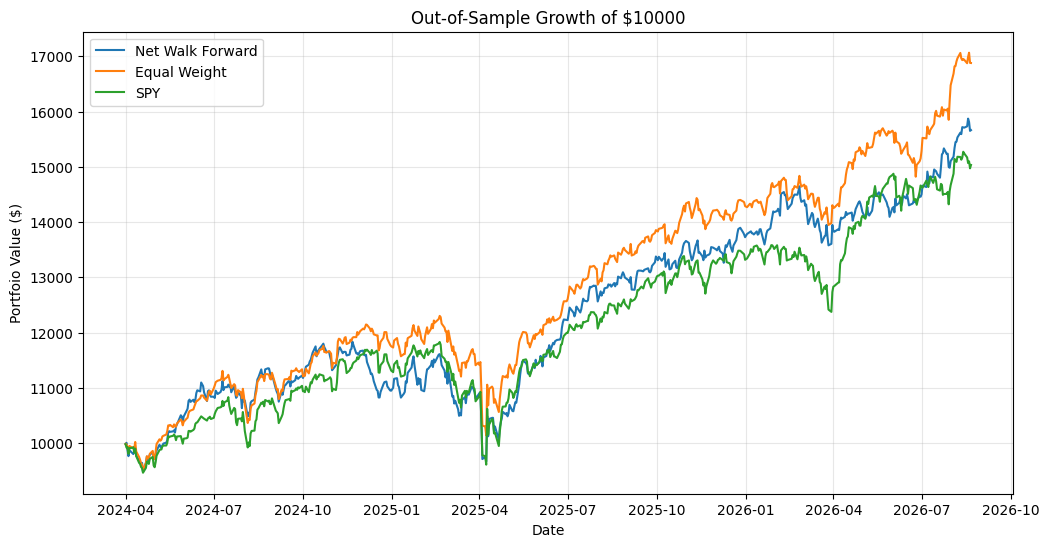

In [992]:
plt.figure(figsize=(12, 6))
for column in comparison_wealth.columns:
    plt.plot(
        comparison_wealth.index,
        comparison_wealth[column],
        label = column
    )


plt.title("Out-of-Sample Growth of $10000")
plt.xlabel("Date")
plt.ylabel("Portfoio Value ($)")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()


In [993]:
# Calculate drawdowns for all three strategies
comparison_drawdowns = pd.DataFrame(index=final_comparison_returns.index)

for column in final_comparison_returns.columns:
    wealth = (1+ final_comparison_returns[column]).cumprod()

    running_peak = wealth.cummax()

    drawdown = (wealth / running_peak - 1)

    comparison_drawdowns[column] = drawdown


comparison_drawdowns.head()

,Net Walk Forward,Equal Weight,SPY
Date,,,
2024-04-01,0.000000,0.000000,0.000000
2024-04-02,0.000000,-0.000901,-0.006358
2024-04-03,-0.012930,-0.006604,-0.005266
2024-04-04,-0.024181,-0.016361,-0.017408
2024-04-05,-0.013414,-0.003835,-0.007143


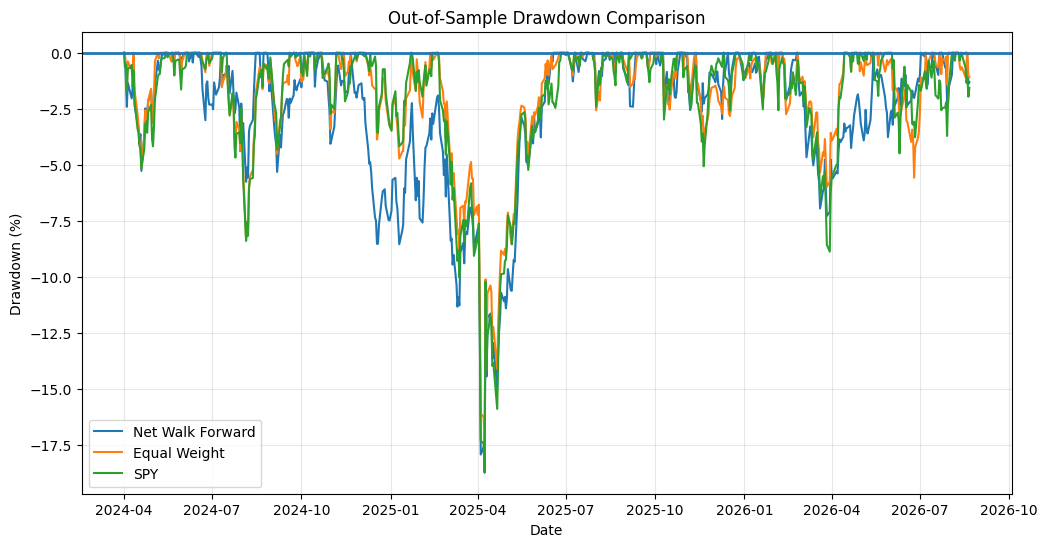

In [994]:
plt.figure(figsize=(12, 6))

for column in comparison_drawdowns.columns:

    plt.plot(
        comparison_drawdowns.index,
        comparison_drawdowns[column] * 100,
        label=column
    )

plt.axhline(
    y=0,
    linewidth=2
)

plt.title(
    "Out-of-Sample Drawdown Comparison"
)

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [995]:
# identifying the exactly when each worst drawdown occurred

for column in comparison_drawdowns.columns:
    worst_date = (comparison_drawdowns[column].idxmin())
    worst_drawdown = (comparison_drawdowns[column].min())


    print(f"{column}: "
        f"{worst_drawdown:.2%} "
        f"on {worst_date.date()}")


Net Walk Forward: -18.32% on 2025-04-08
Equal Weight: -17.57% on 2025-04-08
SPY: -18.76% on 2025-04-08


In [996]:
rolling_window = 63

rolling_sharpe = pd.DataFrame(
    index=final_comparison_returns.index
)

for column in final_comparison_returns.columns:

    rolling_mean = (
        final_comparison_returns[column]
        .rolling(rolling_window)
        .mean()
        * 252
    )

    rolling_volatility = (
        final_comparison_returns[column]
        .rolling(rolling_window)
        .std()
        * np.sqrt(252)
    )

    rolling_sharpe[column] = (
        rolling_mean / rolling_volatility
    )

rolling_sharpe.tail()

,Net Walk Forward,Equal Weight,SPY
Date,,,
2026-08-17,3.062458,2.604627,1.435356
2026-08-18,3.190752,2.705084,1.251625
2026-08-19,3.187772,3.052173,1.514124
2026-08-20,2.706938,2.487021,0.971438
2026-08-21,2.776718,2.418783,1.031785


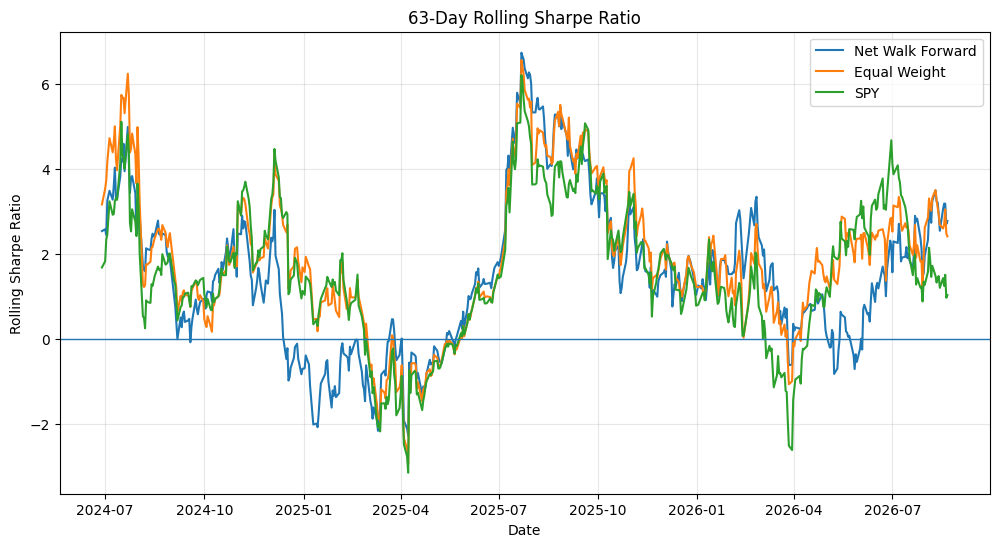

In [997]:
plt.figure(figsize=(12, 6))

for column in rolling_sharpe.columns:

    plt.plot(
        rolling_sharpe.index,
        rolling_sharpe[column],
        label=column
    )

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "63-Day Rolling Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")

plt.legend()
plt.grid(alpha=0.3)

plt.show()